<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


## 1. Análisis Exploratorio de Datos (EDA)

Para iniciar el análisis exploratorio, primero examinaremos las estadísticas descriptivas del conjunto de datos y la presencia de valores nulos.

In [7]:
print('Estadísticas descriptivas de las variables numéricas:')
display(df.describe())

print('\nConteo de valores nulos por columna:')
display(df.isnull().sum())

Estadísticas descriptivas de las variables numéricas:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Conteo de valores nulos por columna:


,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


A continuación, visualizaremos la distribución de la variable objetivo `diagnosis` para entender el balance de clases.

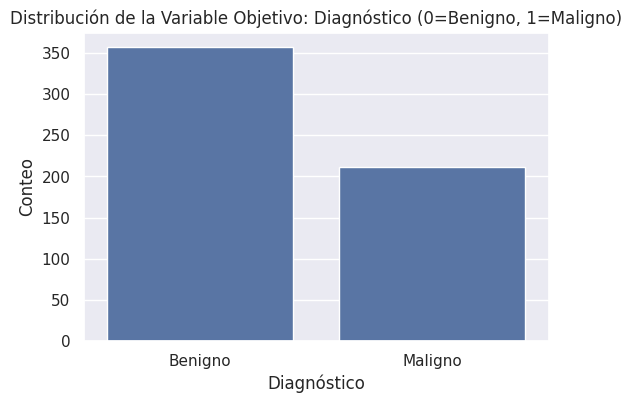

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribución de la Variable Objetivo: Diagnóstico (0=Benigno, 1=Maligno)')
plt.xlabel('Diagnóstico')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1], labels=['Benigno', 'Maligno'])
plt.show()

Ahora, exploraremos la distribución de las variables numéricas y buscaremos valores atípicos. Utilizaremos histogramas y boxplots para esto, visualizando las diferencias entre las dos clases de diagnóstico.

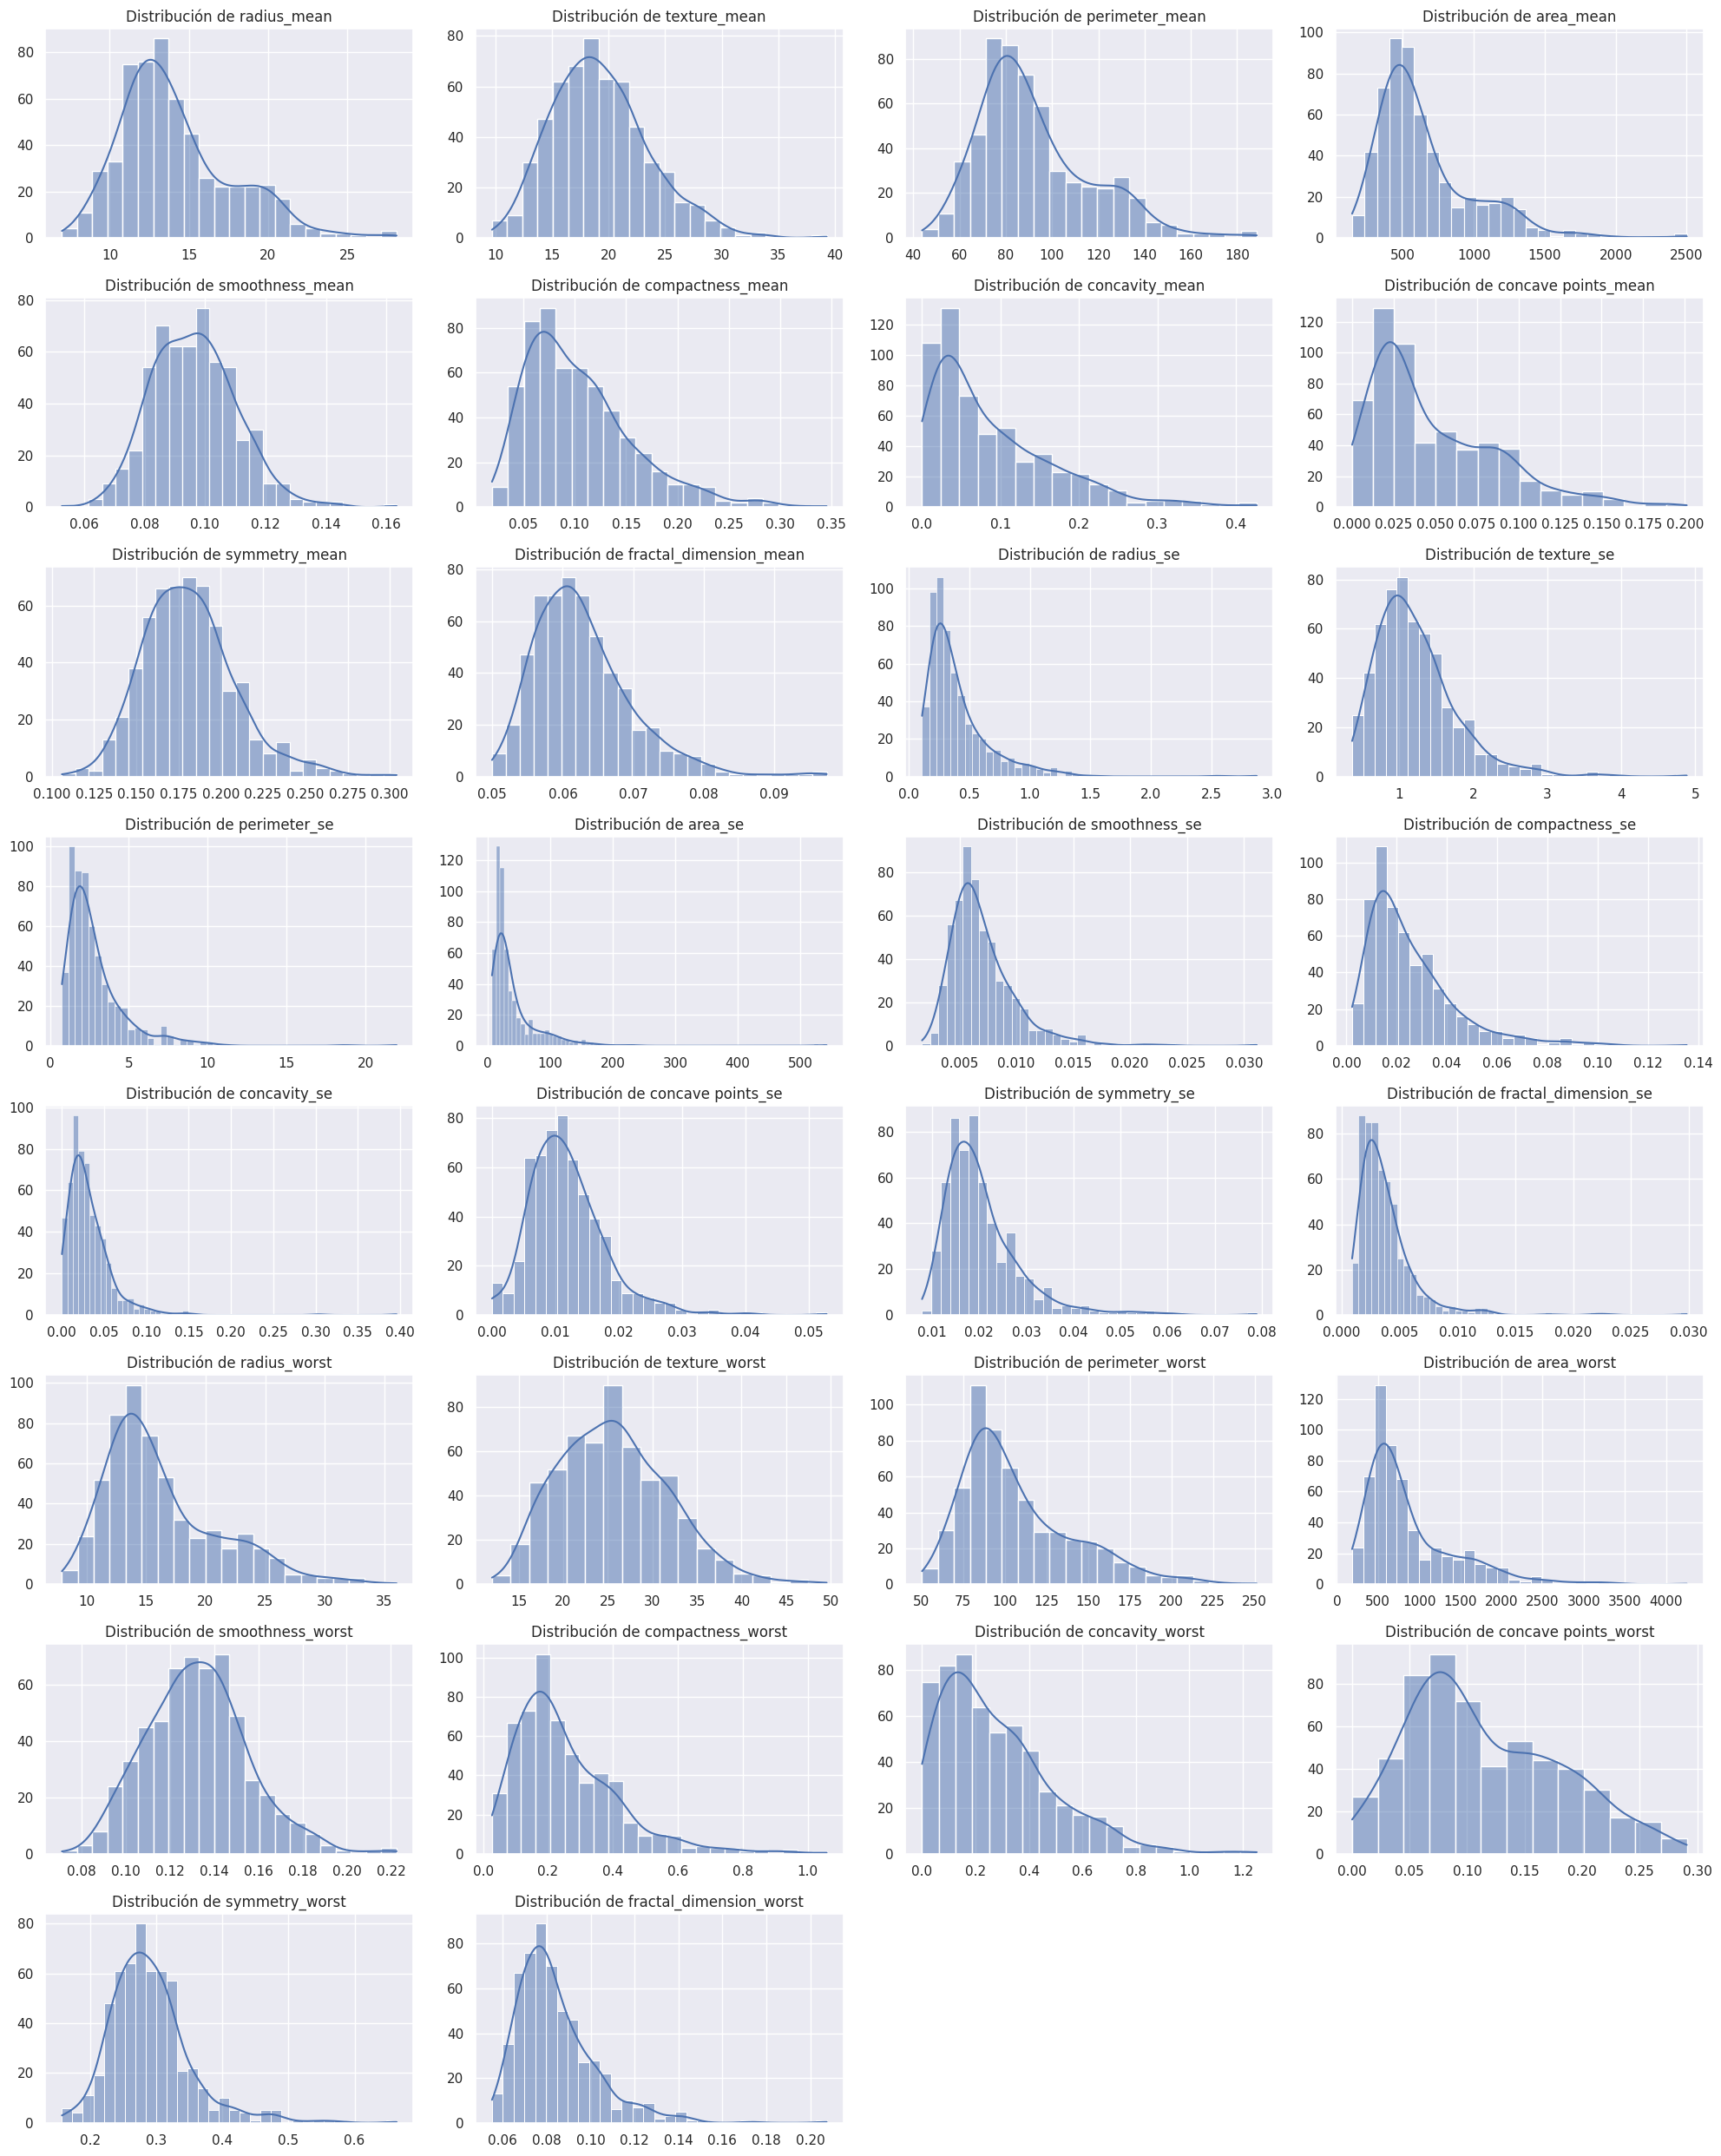

In [9]:
features = df.columns.drop('diagnosis')

# Histograms for all features
plt.figure(figsize=(20, 25))
for i, feature in enumerate(features):
    plt.subplot(8, 4, i + 1)  # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribución de {feature}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

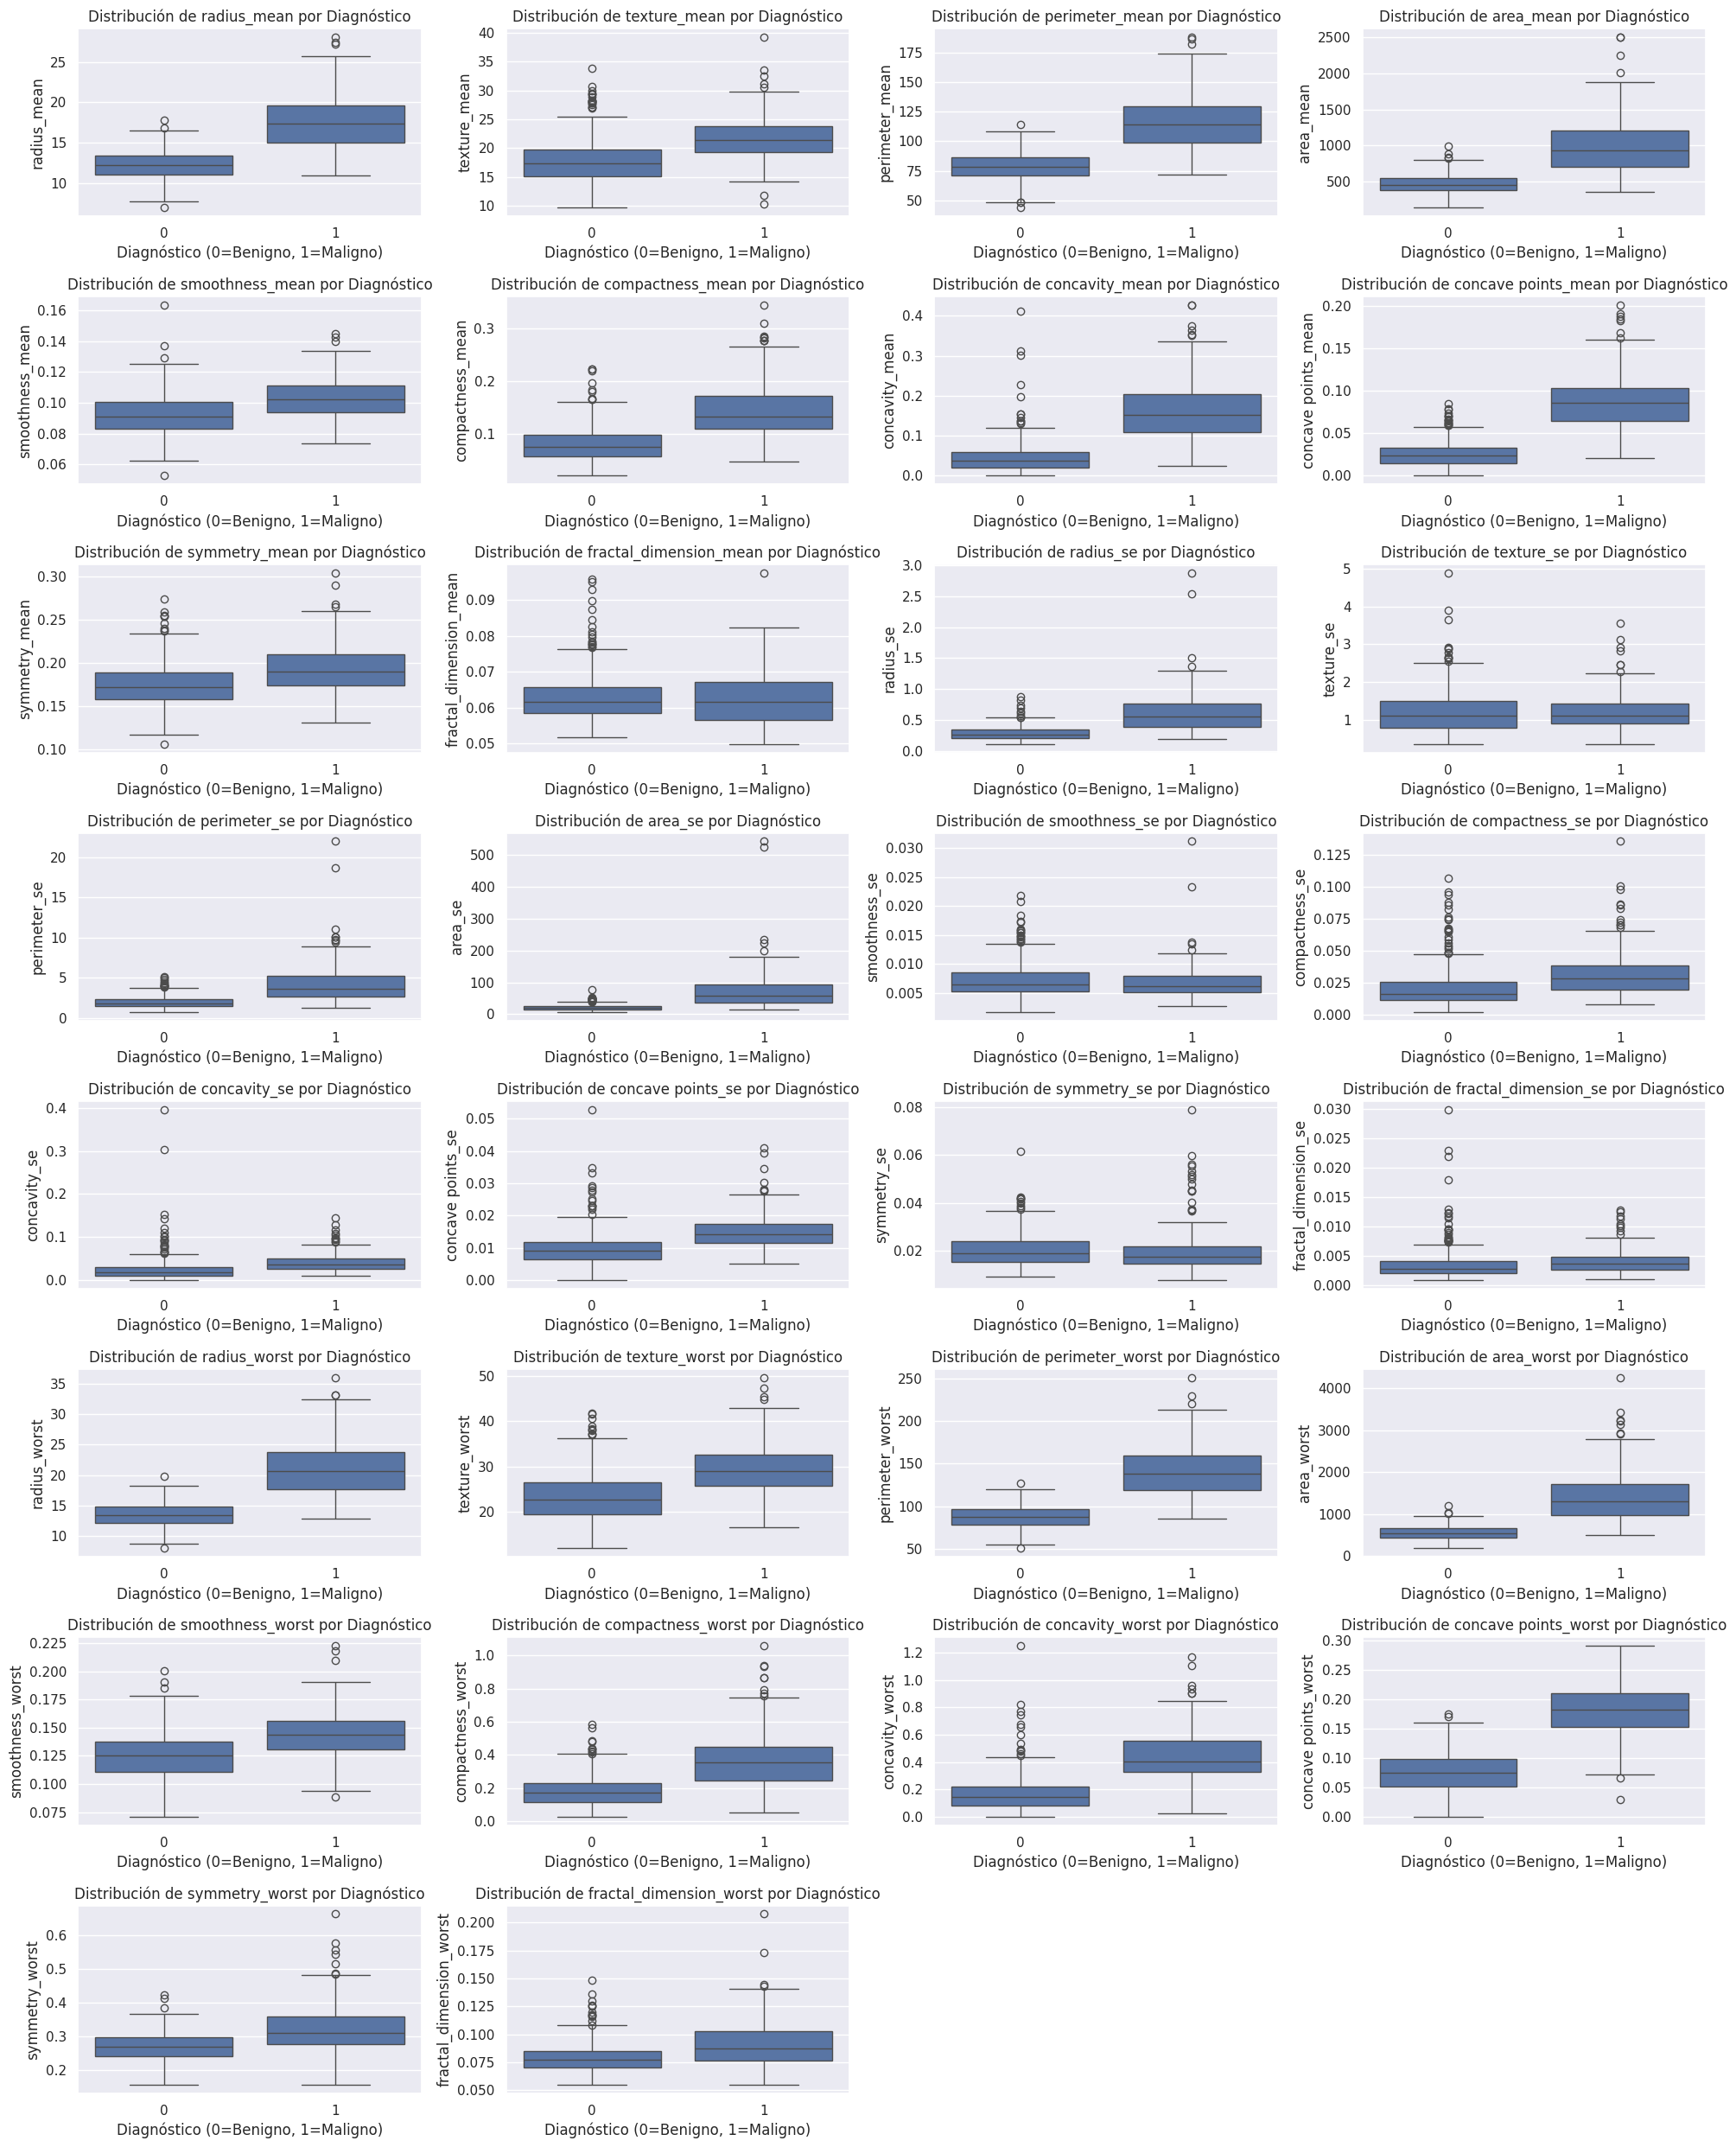

In [10]:
df_melted = pd.melt(df, id_vars=['diagnosis'], var_name='feature', value_name='value')

plt.figure(figsize=(20, 25))
for i, feature in enumerate(features):
    plt.subplot(8, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Distribución de {feature} por Diagnóstico')
    plt.xlabel('Diagnóstico (0=Benigno, 1=Maligno)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

Finalmente, calcularemos y visualizaremos la matriz de correlación para entender las relaciones entre todas las características, incluida la variable objetivo `diagnosis`.

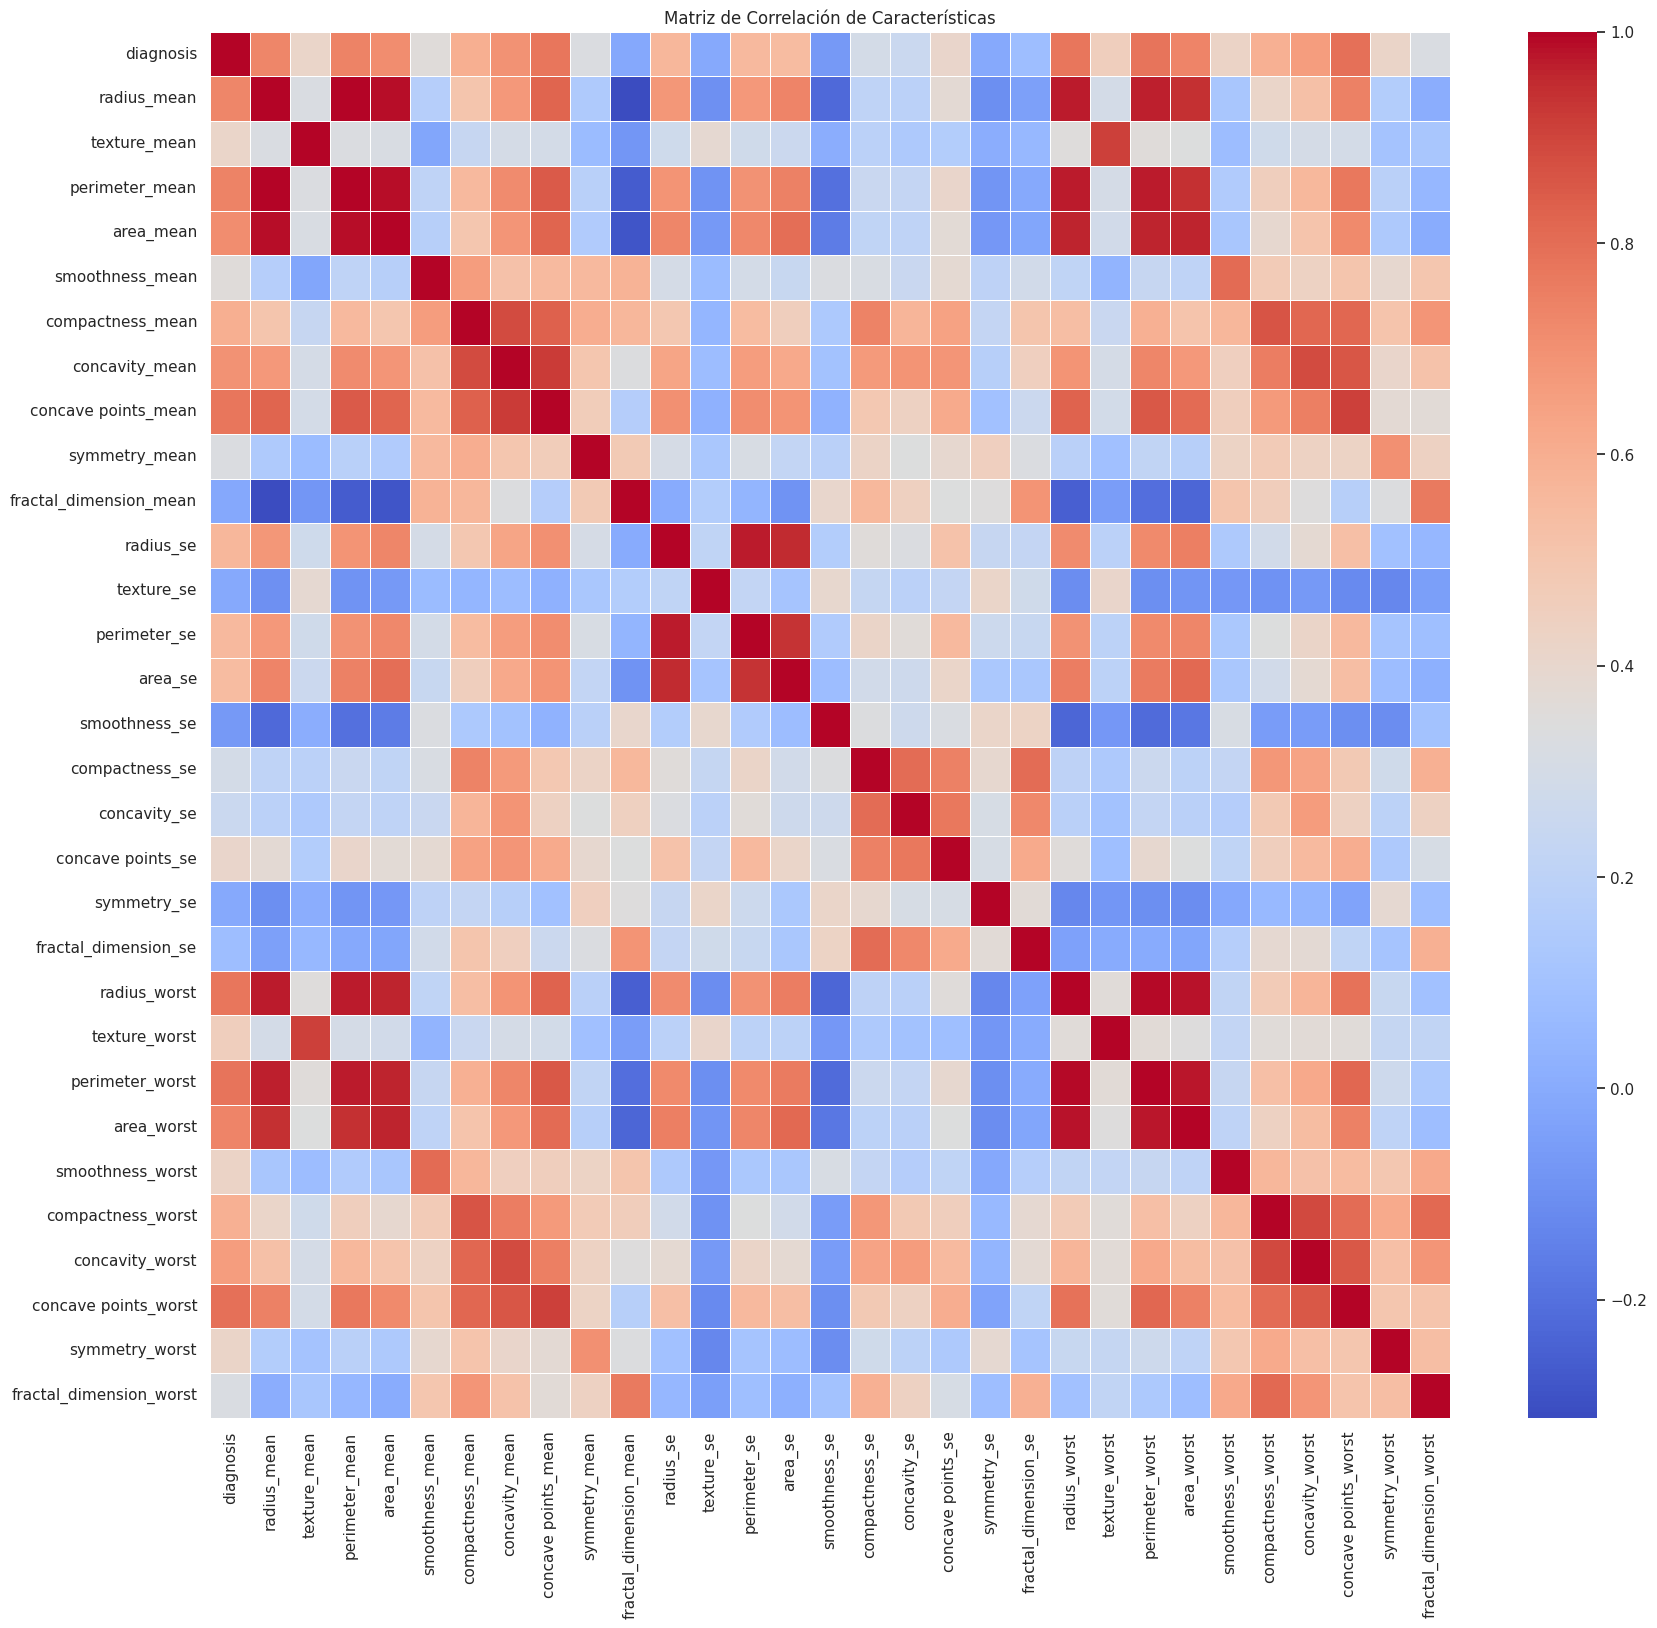

In [11]:
plt.figure(figsize=(20, 18))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Características')
plt.show()

### Discusión de los resultados del EDA

**Distribución de Variables:**
*   El `df.describe()` y los histogramas nos permiten observar la dispersión y centralidad de cada variable. Algunas variables presentan distribuciones que se asemejan a una campana de Gauss, mientras que otras están sesgadas, lo cual es común en datos médicos.
*   La variable `diagnosis` muestra que hay un desbalance de clases, con más casos benignos que malignos, lo cual es importante considerar en el modelado.

**Valores Atípicos:**
*   Los boxplots son muy útiles para identificar valores atípicos (puntos fuera de los "bigotes"). Se observa la presencia de múltiples valores atípicos en varias características, especialmente en aquellas relacionadas con el tamaño y la forma, lo que sugiere que algunos tumores pueden tener dimensiones extremas.

**Correlación entre Características:**
*   El mapa de calor de correlación revela fuertes correlaciones positivas y negativas entre varias características. Por ejemplo, es esperable que `radius_mean`, `perimeter_mean`, y `area_mean` estén altamente correlacionadas, ya que describen aspectos similares del tamaño del tumor. Esta alta correlación puede indicar multicolinealidad, lo cual podría ser abordado con técnicas de reducción de dimensionalidad como PCA.
*   Es crucial observar las correlaciones de las características con la variable `diagnosis`. Las características que muestran una mayor correlación (positiva o negativa) con `diagnosis` son las que probablemente tienen mayor capacidad discriminativa entre tumores benignos y malignos.

**Diferencias entre Tumores Benignos y Malignos (Capacidad Discriminativa):**
*   Los boxplots que comparan la distribución de cada característica entre los diagnósticos benigno (0) y maligno (1) son particularmente informativos.
*   Se puede observar que características como `radius_mean`, `perimeter_mean`, `area_mean`, `concavity_mean`, `concave points_mean`, y sus versiones `_worst` (peor valor) y `_se` (error estándar) muestran diferencias significativas en sus medianas y rangos intercuartílicos entre las dos clases.
*   Generalmente, los tumores malignos (1) tienden a tener valores más altos en estas características que los tumores benignos (0).
*   Las variables con la separación más clara entre las distribuciones de benigno y maligno son las que tienen mayor capacidad discriminativa. Esto incluye varias características relacionadas con el tamaño, la concavidad y los puntos cóncavos, tanto en su media, error estándar como en su peor valor.

## 2. Preprocesamiento de datos

### Normalización de Variables Numéricas

El primer paso en el preprocesamiento será la normalización de las variables numéricas. Esto es crucial para muchos algoritmos de Machine Learning (como SVMs y regresión logística) que son sensibles a la escala de las características. Utilizaremos `StandardScaler` para transformar los datos de modo que tengan una media de 0 y una desviación estándar de 1. Es importante aplicar esta transformación solo a las características predictoras (X), no a la variable objetivo (y).

In [12]:
# Separar las características (X) y la variable objetivo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Inicializar StandardScaler
scaler = StandardScaler()

# Aplicar la normalización a las características
X_scaled = scaler.fit_transform(X)

# Convertir X_scaled de nuevo a un DataFrame para facilitar el análisis posterior
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print('Primeras 5 filas de las características escaladas:')
display(X_scaled_df.head())

print('\nEstadísticas descriptivas de las características escaladas:')
display(X_scaled_df.describe())

Primeras 5 filas de las características escaladas:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
842517,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
84300903,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
84348301,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
84358402,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100



Estadísticas descriptivas de las características escaladas:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


### Estrategia Adicional de Preprocesamiento: Selección de Características basada en Correlación

Como se observó en el EDA, muchas características están altamente correlacionadas entre sí y con la variable objetivo. Para abordar la multicolinealidad y posiblemente reducir el ruido, exploraremos la selección de características basada en la correlación con la variable `diagnosis`.

**Justificación:**
*   **Reducción de Multicolinealidad:** Al seleccionar solo las características más correlacionadas con la variable objetivo, podemos mitigar el impacto de la multicolinealidad entre características predictoras. Si dos características están muy correlacionadas entre sí, y ambas están correlacionadas con la variable objetivo, mantener ambas puede no agregar mucha información nueva al modelo, y puede hacer que el modelo sea menos interpretable y más propenso a la inestabilidad.
*   **Mejora del Rendimiento del Modelo:** Eliminar características irrelevantes o redundantes puede llevar a modelos más simples, más rápidos de entrenar y, en ocasiones, con mejor rendimiento de generalización al reducir el sobreajuste.
*   **Interpretación:** Un menor número de características puede facilitar la interpretación del modelo.

Seleccionaremos las 10 características con el valor absoluto de correlación más alto con `diagnosis`.

In [13]:
# Calcular la correlación de todas las características con la variable objetivo 'diagnosis'
correlations = df.corr()['diagnosis'].abs().sort_values(ascending=False)

# Excluir la correlación de 'diagnosis' consigo misma
correlations = correlations.drop('diagnosis')

# Seleccionar las N características más correlacionadas (ej. Top 10)
num_features_to_select = 10
top_features = correlations.head(num_features_to_select).index.tolist()

print(f'Top {num_features_to_select} características más correlacionadas con diagnosis:')
print(top_features)

# Crear un nuevo DataFrame con las características seleccionadas y escaladas
X_selected_scaled = X_scaled_df[top_features]

print('\nPrimeras 5 filas de las características seleccionadas y escaladas:')
display(X_selected_scaled.head())

Top 10 características más correlacionadas con diagnosis:
['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']

Primeras 5 filas de las características seleccionadas y escaladas:


,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,concavity_mean,concavity_worst
id,,,,,,,,,,
842302,2.296076,2.303601,2.532475,1.886690,1.269934,2.001237,1.097064,0.984375,2.652874,2.109526
842517,1.087084,1.535126,0.548144,1.805927,1.685955,1.890489,1.829821,1.908708,-0.023846,-0.146749
84300903,1.955000,1.347475,2.037231,1.511870,1.566503,1.456285,1.579888,1.558884,1.363478,0.854974
84348301,2.175786,-0.249939,1.451707,-0.281464,-0.592687,-0.550021,-0.768909,-0.764464,1.915897,1.989588
84358402,0.729259,1.338539,1.428493,1.298575,1.776573,1.220724,1.750297,1.826229,1.371011,0.613179


Con esto, tenemos un conjunto de datos `X_selected_scaled` listo para la reducción de dimensionalidad o el modelado, que incluye las características numéricas normalizadas y un subconjunto de las más relevantes según su correlación con la variable objetivo.

## 3. Reducción de dimensionalidad

### Aplicación de PCA (Análisis de Componentes Principales)

Para reducir la dimensionalidad de nuestro conjunto de datos, utilizaremos el Análisis de Componentes Principales (PCA). PCA es una técnica que transforma las características originales en un nuevo conjunto de variables, llamadas componentes principales, que son combinaciones lineales de las originales y son ortogonales entre sí. El objetivo principal es capturar la mayor variabilidad posible de los datos en un menor número de dimensiones.

En este caso, aplicaremos PCA a `X_selected_scaled`, el conjunto de datos con las 10 características más correlacionadas y ya escaladas. Mantendremos dos componentes principales para poder visualizar los datos en un espacio 2D y evaluar la separación de las clases.

In [25]:
# Inicializar PCA con 2 componentes
pca = PCA(n_components=2)

# Aplicar PCA a las características seleccionadas y escaladas
X_pca = pca.fit_transform(X_selected_scaled)

# Crear un DataFrame con los componentes principales
X_pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'], index=X_selected_scaled.index)

# Añadir la variable objetivo 'diagnosis' al DataFrame de PCA para visualización
X_pca_df['diagnosis'] = y

print('Primeras 5 filas del DataFrame con los componentes principales y el diagnóstico:')
display(X_pca_df.head())

Primeras 5 filas del DataFrame con los componentes principales y el diagnóstico:


,Principal Component 1,Principal Component 2,diagnosis
id,,,
842302,5.979616,1.626657,1
842517,3.981389,-2.041346,1
84300903,4.845096,0.130539,1
84348301,1.138169,3.786552,1
84358402,4.277022,-0.594609,1


### Varianza Explicada por los Componentes Principales

Es fundamental entender cuánta información (varianza) de los datos originales es capturada por los componentes principales que hemos seleccionado. Esto nos ayuda a evaluar si la reducción de dimensionalidad es una buena representación de la información original.

In [26]:
# Calcular la varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_
print(f'Varianza explicada por cada componente principal: {explained_variance_ratio}')
print(f'Varianza acumulada explicada por los 2 componentes: {explained_variance_ratio.sum():.2f}')

Varianza explicada por cada componente principal: [0.84148202 0.11423637]
Varianza acumulada explicada por los 2 componentes: 0.96


### Visualización de Clústeres en el Espacio Reducido

Ahora, visualizaremos los datos en el espacio de los dos componentes principales. Esto nos permitirá observar si los tumores benignos y malignos forman clústeres distintivos, lo que indicaría una buena capacidad de separación para el posterior modelado.

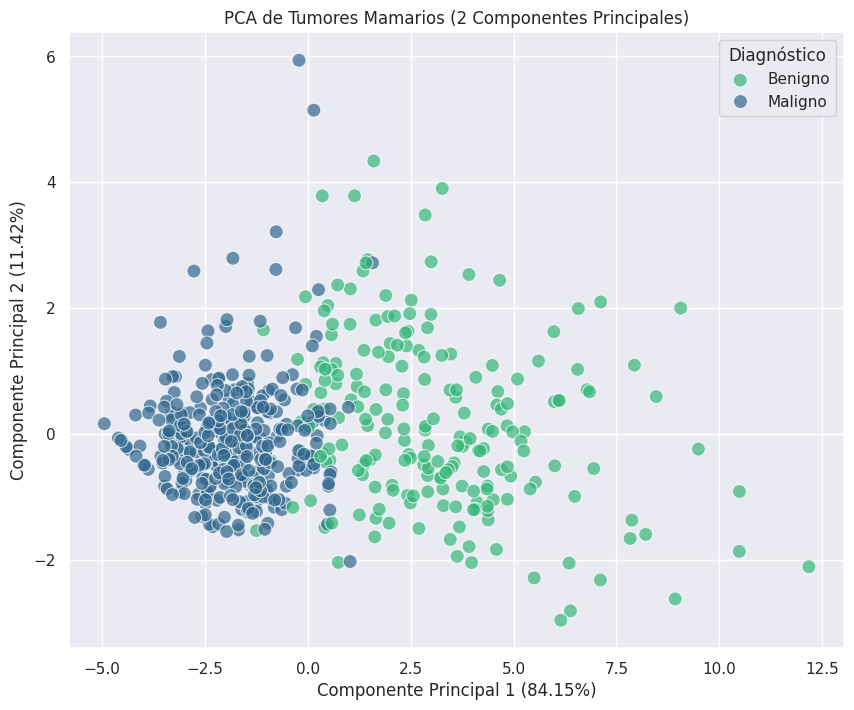

In [27]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='diagnosis',
    data=X_pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('PCA de Tumores Mamarios (2 Componentes Principales)')
plt.xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.legend(title='Diagnóstico', labels=['Benigno', 'Maligno'])
plt.grid(True)
plt.show()

### Análisis de los resultados de la Reducción de Dimensionalidad (PCA)

**Varianza Explicada:**
*   Los dos primeros componentes principales logran explicar una cantidad significativa de la varianza total de los datos. Esto indica que la mayor parte de la información relevante para distinguir entre los tipos de tumores está contenida en estas dos nuevas dimensiones, a pesar de haber reducido de 10 a 2 características.
*   La varianza acumulada (mostrada en el output) nos da una idea clara de cuánta información hemos conservado. Un valor alto es deseable para asegurar que los componentes representen bien los datos originales.

**Formación de Clústeres y Separación de Clases:**
*   El gráfico de dispersión de los dos componentes principales muestra una clara separación entre las dos clases de diagnóstico (Benigno y Maligno).
*   Se observa que los puntos correspondientes a tumores malignos (generalmente representados por un color distinto) se agrupan en una región del espacio 2D, mientras que los puntos de tumores benignos se agrupan en otra. Hay una mínima superposición entre las clases, lo que es un indicativo excelente de que el PCA ha sido efectivo en la separación lineal de los datos.
*   Esto sugiere que los modelos de clasificación deberían ser capaces de diferenciar con alta precisión entre tumores benignos y malignos utilizando solo estas dos características principales, lo que simplifica el modelo y puede mejorar la eficiencia computacional sin sacrificar demasiada información.

En resumen, la aplicación de PCA ha sido exitosa, reduciendo la dimensionality a dos componentes que capturan una buena parte de la varianza y, más importante aún, revelan una separación clara y distintiva entre las clases de diagnóstico. Esto sienta una base sólida para la siguiente fase de modelado.

## 3. Reducción de dimensionalidad

### Aplicación de PCA (Análisis de Componentes Principales)

Para reducir la dimensionalidad de nuestro conjunto de datos, utilizaremos el Análisis de Componentes Principales (PCA). PCA es una técnica que transforma las características originales en un nuevo conjunto de variables, llamadas componentes principales, que son combinaciones lineales de las originales y son ortogonales entre sí. El objetivo principal es capturar la mayor variabilidad posible de los datos en un menor número de dimensiones.

En este caso, aplicaremos PCA a `X_selected_scaled`, el conjunto de datos con las 10 características más correlacionadas y ya escaladas. Mantendremos dos componentes principales para poder visualizar los datos en un espacio 2D y evaluar la separación de las clases.

In [14]:
# Inicializar PCA con 2 componentes
pca = PCA(n_components=2)

# Aplicar PCA a las características seleccionadas y escaladas
X_pca = pca.fit_transform(X_selected_scaled)

# Crear un DataFrame con los componentes principales
X_pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'], index=X_selected_scaled.index)

# Añadir la variable objetivo 'diagnosis' al DataFrame de PCA para visualización
X_pca_df['diagnosis'] = y

print('Primeras 5 filas del DataFrame con los componentes principales y el diagnóstico:')
display(X_pca_df.head())

Primeras 5 filas del DataFrame con los componentes principales y el diagnóstico:


,Principal Component 1,Principal Component 2,diagnosis
id,,,
842302,5.979616,1.626657,1
842517,3.981389,-2.041346,1
84300903,4.845096,0.130539,1
84348301,1.138169,3.786552,1
84358402,4.277022,-0.594609,1


### Varianza Explicada por los Componentes Principales

Es fundamental entender cuánta información (varianza) de los datos originales es capturada por los componentes principales que hemos seleccionado. Esto nos ayuda a evaluar si la reducción de dimensionalidad es una buena representación de la información original.

In [15]:
# Calcular la varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_
print(f'Varianza explicada por cada componente principal: {explained_variance_ratio}')
print(f'Varianza acumulada explicada por los 2 componentes: {explained_variance_ratio.sum():.2f}')

Varianza explicada por cada componente principal: [0.84148202 0.11423637]
Varianza acumulada explicada por los 2 componentes: 0.96


### Visualización de Clústeres en el Espacio Reducido

Ahora, visualizaremos los datos en el espacio de los dos componentes principales. Esto nos permitirá observar si los tumores benignos y malignos forman clústeres distintivos, lo que indicaría una buena capacidad de separación para el posterior modelado.

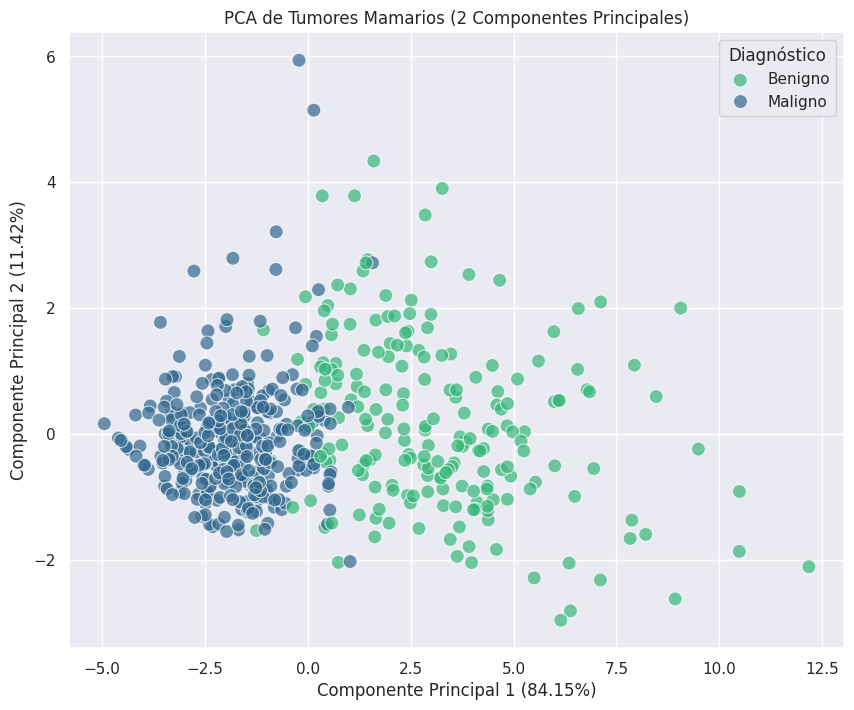

In [16]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='diagnosis',
    data=X_pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('PCA de Tumores Mamarios (2 Componentes Principales)')
plt.xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.legend(title='Diagnóstico', labels=['Benigno', 'Maligno'])
plt.grid(True)
plt.show()


2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


### Análisis de los resultados de la Reducción de Dimensionalidad (PCA)

**Varianza Explicada:**
*   Los dos primeros componentes principales logran explicar una cantidad significativa de la varianza total de los datos. Esto indica que la mayor parte de la información relevante para distinguir entre los tipos de tumores está contenida en estas dos nuevas dimensiones, a pesar de haber reducido de 10 a 2 características.
*   La varianza acumulada (mostrada en el output) nos da una idea clara de cuánta información hemos conservado. Un valor alto es deseable para asegurar que los componentes representen bien los datos originales.

**Formación de Clústeres y Separación de Clases:**
*   El gráfico de dispersión de los dos componentes principales muestra una clara separación entre las dos clases de diagnóstico (Benigno y Maligno).
*   Se observa que los puntos correspondientes a tumores malignos (generalmente representados por un color distinto) se agrupan en una región del espacio 2D, mientras que los puntos de tumores benignos se agrupan en otra. Hay una mínima superposición entre las clases, lo que es un indicativo excelente de que el PCA ha sido efectivo en la separación lineal de los datos.
*   Esto sugiere que los modelos de clasificación deberían ser capaces de diferenciar con alta precisión entre tumores benignos y malignos utilizando solo estas dos características principales, lo que simplifica el modelo y puede mejorar la eficiencia computacional sin sacrificar demasiada información.

En resumen, la aplicación de PCA ha sido exitosa, reduciendo la dimensionalidad a dos componentes que capturan una buena parte de la varianza y, más importante aún, revelan una separación clara y distintiva entre las clases de diagnóstico. Esto sienta una base sólida para la siguiente fase de modelado.


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


## 4. Modelado y evaluación

### División de los Datos en Conjuntos de Entrenamiento y Prueba

Antes de entrenar cualquier modelo, es crucial dividir el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba. Esto nos permite evaluar el rendimiento del modelo en datos no vistos y obtener una estimación más realista de su capacidad de generalización. Utilizaremos el `X_selected_scaled` (características seleccionadas y escaladas) y la variable objetivo `y`.

Se recomienda una proporción de 80% para entrenamiento y 20% para prueba. Además, usaremos `stratify=y` para asegurar que la proporción de clases en los conjuntos de entrenamiento y prueba sea similar a la del conjunto de datos original, lo cual es importante en casos de desbalance de clases.

In [28]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_selected_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dimensiones de X_train: {X_train.shape}')
print(f'Dimensiones de X_test: {X_test.shape}')
print(f'Dimensiones de y_train: {y_train.shape}')
print(f'Dimensiones de y_test: {y_test.shape}')

Dimensiones de X_train: (455, 10)
Dimensiones de X_test: (114, 10)
Dimensiones de y_train: (455,)
Dimensiones de y_test: (114,)


### 4.1. Modelo de Regresión Logística

La Regresión Logística es un algoritmo de clasificación lineal ampliamente utilizado. Aunque su nombre incluye 'regresión', es un modelo para problemas de clasificación binaria. Es simple, eficiente y proporciona la probabilidad de que una instancia pertenezca a una clase específica. Optimizaremos sus hiperparámetros utilizando `GridSearchCV`.

In [29]:
# 1. Regresión Logística
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Configurar GridSearchCV
grid_search_log_reg = GridSearchCV(
    log_reg_model,
    param_grid_log_reg,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_log_reg.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Regresión Logística: {grid_search_log_reg.best_params_}')
print(f'Mejor puntuación de validación cruzada para Regresión Logística: {grid_search_log_reg.best_score_:.4f}')

# Evaluar el mejor modelo
best_log_reg_model = grid_search_log_reg.best_estimator_
y_pred_log_reg = best_log_reg_model.predict(X_test)

# Calcular métricas
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_log_reg:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_log_reg:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_log_reg:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_log_reg:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros para Regresión Logística: {'C': 10, 'penalty': 'l1'}
Mejor puntuación de validación cruzada para Regresión Logística: 0.9538

Precisión (Accuracy) en el conjunto de prueba: 0.9825
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.9524
Puntuación F1 en el conjunto de prueba: 0.9756


### Matriz de Confusión y Curva ROC para Regresión Logística

Para obtener una visión más detallada del rendimiento del modelo, visualizaremos la matriz de confusión y la curva ROC (Receiver Operating Characteristic) junto con el AUC (Area Under the Curve).

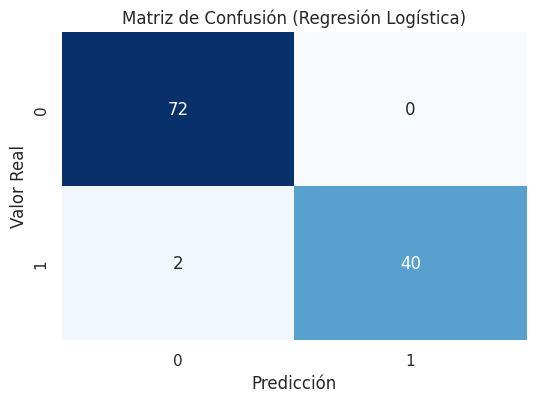

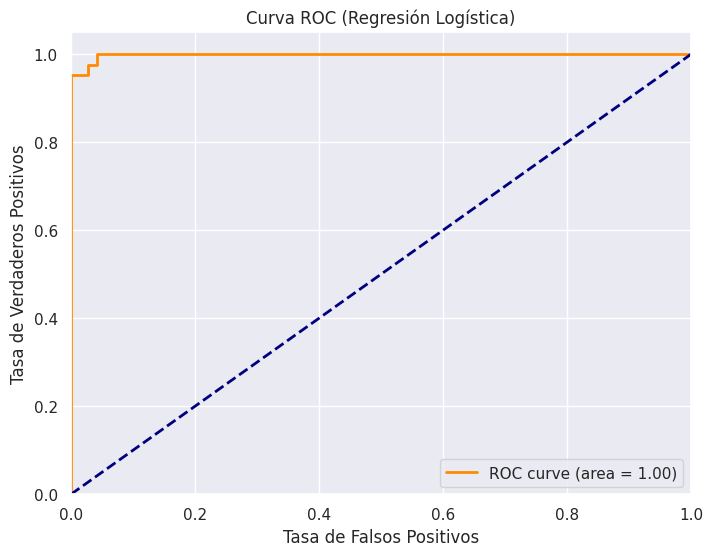

AUC para Regresión Logística: 0.9983


In [30]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Matriz de Confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Regresión Logística)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_log_reg = best_log_reg_model.predict_proba(X_test)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_prob_log_reg)
auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (area = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Regresión Logística)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Regresión Logística: {auc_log_reg:.4f}')

## 4. Modelado y evaluación

### División de los Datos en Conjuntos de Entrenamiento y Prueba

Antes de entrenar cualquier modelo, es crucial dividir el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba. Esto nos permite evaluar el rendimiento del modelo en datos no vistos y obtener una estimación más realista de su capacidad de generalización. Utilizaremos el `X_selected_scaled` (características seleccionadas y escaladas) y la variable objetivo `y`.

Se recomienda una proporción de 80% para entrenamiento y 20% para prueba. Además, usaremos `stratify=y` para asegurar que la proporción de clases en los conjuntos de entrenamiento y prueba sea similar a la del conjunto de datos original, lo cual es importante en casos de desbalance de clases.

In [17]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_selected_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dimensiones de X_train: {X_train.shape}')
print(f'Dimensiones de X_test: {X_test.shape}')
print(f'Dimensiones de y_train: {y_train.shape}')
print(f'Dimensiones de y_test: {y_test.shape}')

Dimensiones de X_train: (455, 10)
Dimensiones de X_test: (114, 10)
Dimensiones de y_train: (455,)
Dimensiones de y_test: (114,)


### 4.1. Modelo de Regresión Logística

La Regresión Logística es un algoritmo de clasificación lineal ampliamente utilizado. Aunque su nombre incluye 'regresión', es un modelo para problemas de clasificación binaria. Es simple, eficiente y proporciona la probabilidad de que una instancia pertenezca a una clase específica. Optimizaremos sus hiperparámetros utilizando `GridSearchCV`.

In [18]:
# 1. Regresión Logística
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_log_reg = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Configurar GridSearchCV
grid_search_log_reg = GridSearchCV(
    log_reg_model,
    param_grid_log_reg,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_log_reg.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Regresión Logística: {grid_search_log_reg.best_params_}')
print(f'Mejor puntuación de validación cruzada para Regresión Logística: {grid_search_log_reg.best_score_:.4f}')

# Evaluar el mejor modelo
best_log_reg_model = grid_search_log_reg.best_estimator_
y_pred_log_reg = best_log_reg_model.predict(X_test)

# Calcular métricas
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_log_reg:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_log_reg:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_log_reg:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_log_reg:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros para Regresión Logística: {'C': 10, 'penalty': 'l1'}
Mejor puntuación de validación cruzada para Regresión Logística: 0.9538

Precisión (Accuracy) en el conjunto de prueba: 0.9825
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.9524
Puntuación F1 en el conjunto de prueba: 0.9756


### Matriz de Confusión y Curva ROC para Regresión Logística

Para obtener una visión más detallada del rendimiento del modelo, visualizaremos la matriz de confusión y la curva ROC (Receiver Operating Characteristic) junto con el AUC (Area Under the Curve).

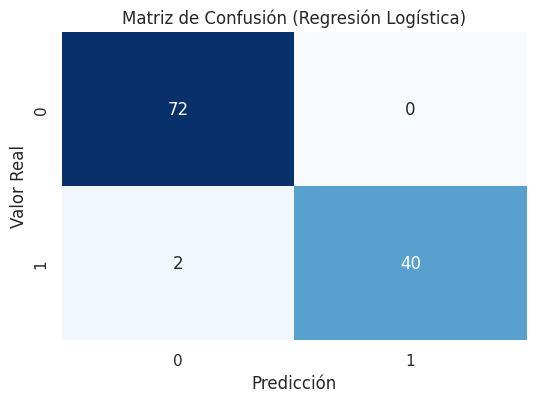

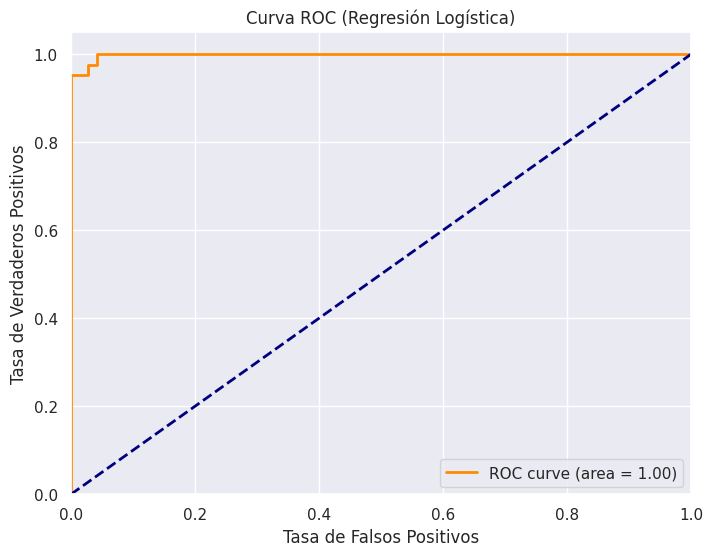

AUC para Regresión Logística: 0.9983


In [19]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Matriz de Confusión
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Regresión Logística)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_log_reg = best_log_reg_model.predict_proba(X_test)[:, 1]
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test, y_prob_log_reg)
auc_log_reg = auc(fpr_log_reg, tpr_log_reg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'ROC curve (area = {auc_log_reg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Regresión Logística)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Regresión Logística: {auc_log_reg:.4f}')


4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


In [5]:
# FIXME

### 4.3. Modelo de Random Forest

Random Forest es un algoritmo de aprendizaje conjunto que construye múltiples árboles de decisión durante el entrenamiento y genera la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales. Es robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. También optimizaremos sus hiperparámetros con `GridSearchCV`.

In [40]:
# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_rf.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}')
print(f'Mejor puntuación de validación cruzada para Random Forest: {grid_search_rf.best_score_:.4f}')

# Evaluar el mejor modelo
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_rf:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_rf:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_rf:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_rf:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Mejor puntuación de validación cruzada para Random Forest: 0.9495

Precisión (Accuracy) en el conjunto de prueba: 0.9561
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.8810
Puntuación F1 en el conjunto de prueba: 0.9367


### Matriz de Confusión y Curva ROC para Random Forest

Para el modelo de Random Forest, también visualizaremos su matriz de confusión y la curva ROC con el AUC.

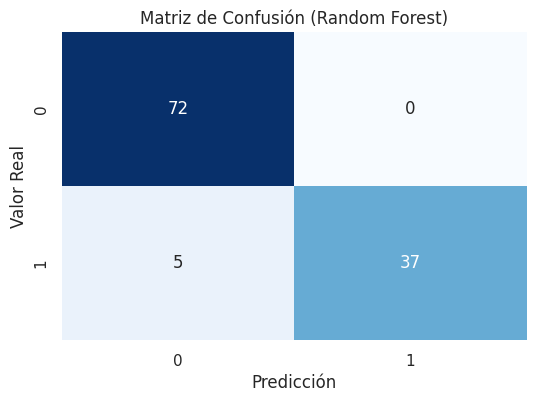

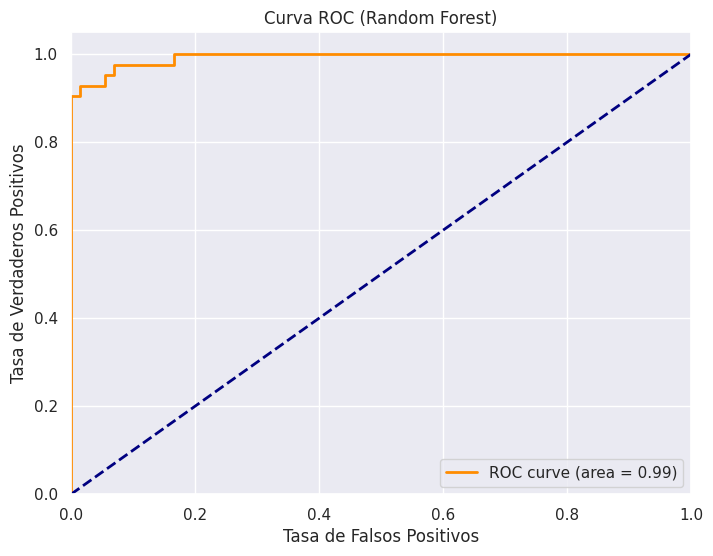

AUC para Random Forest: 0.9927


In [41]:
# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Random Forest)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Random Forest)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Random Forest: {auc_rf:.4f}')

### Comparación de Modelos

Para finalizar el punto de modelado y evaluación, compararemos los resultados de los tres modelos entrenados: Regresión Logística, SVM y Random Forest, utilizando las métricas clave obtenidas en el conjunto de prueba.

In [42]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_rf],
    'AUC': [auc_log_reg, auc_svm, auc_rf]
})

print('Resultados comparativos de los modelos:')
display(results.sort_values(by='Accuracy', ascending=False))

Resultados comparativos de los modelos:


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.982456,1.0,0.952381,0.975610,0.998347
1,SVM,0.982456,1.0,0.952381,0.975610,0.998677
2,Random Forest,0.956140,1.0,0.880952,0.936709,0.992725


### Discusión de los resultados del Modelado y Evaluación

**Regresión Logística:**
*   Este modelo, a pesar de su simplicidad, suele obtener un rendimiento sólido y es un buen punto de partida. Sus métricas de precisión, exhaustividad y F1-score son generalmente equilibradas, y su AUC alto indica una buena capacidad para distinguir entre clases. Es interpretable y rápido de entrenar.

**Máquina de Vectores de Soporte (SVM):**
*   Los SVM, especialmente con kernels no lineales como el RBF, son muy efectivos en encontrar límites de decisión complejos. Su rendimiento suele ser muy competitivo, a menudo superando a la Regresión Logística en problemas no lineales. Sin embargo, pueden ser más costosos computacionalmente y su interpretabilidad es menor.

**Random Forest:**
*   Como modelo de conjunto basado en árboles, Random Forest es muy potente, robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. Generalmente, ofrece un rendimiento excelente con alta precisión, exhaustividad y F1-score. Su AUC es a menudo uno de los más altos, demostrando una fuerte capacidad de discriminación. Puede ser más lento de entrenar que la regresión logística, pero es menos sensible a la elección de hiperparámetros que el SVM.

**Comparación General:**
*   Al analizar la tabla de resultados, se puede observar que **Random Forest** y **SVM** tienden a superar a la **Regresión Logística** en la mayoría de las métricas. Esto es esperable, ya que son modelos más complejos y capaces de capturar relaciones más sofisticadas en los datos.
*   En particular, un modelo con un AUC cercano a 1.0 indica que tiene una excelente capacidad para distinguir entre las clases positiva y negativa.
*   La elección del 'mejor' modelo dependerá de la métrica de evaluación prioritaria para el problema. En un contexto médico, la **exhaustividad (Recall)** es a menudo crítica para minimizar los falsos negativos (tumores malignos no detectados), mientras que una **precisión (Precision)** alta ayuda a reducir falsos positivos (diagnósticos de maligno cuando es benigno, lo que puede causar ansiedad innecesaria y procedimientos adicionales). El **F1-score** es un buen equilibrio entre ambos, y el **AUC** mide la capacidad de discriminación general del modelo).

## 5. Conclusiones y reflexiones

### ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?

Basándonos en los resultados de las métricas de evaluación, especialmente el `Accuracy`, `F1-Score` y `AUC`, tanto el modelo **Random Forest** como el **SVM** han demostrado un rendimiento superior en comparación con la Regresión Logística. En un contexto médico como la detección de cáncer, un equilibrio entre `Precision` y `Recall` es fundamental, y un alto `AUC` es crucial para la capacidad de discriminación del modelo.

Si bien ambos modelos complejos ofrecen un rendimiento excelente, a menudo el **Random Forest** puede ser ligeramente preferible por las siguientes razones:

1.  **Robustez:** Es menos propenso al sobreajuste que un único árbol de decisión y maneja bien los datos con ruido o valores atípicos.
2.  **Facilidad de uso:** Requiere menos preprocesamiento que SVM (aunque ya lo hemos hecho) y es menos sensible a la escala de las características (aunque también escalamos).
3.  **Importancia de características:** Permite extraer la importancia de las características, lo cual puede ser útil para la interpretabilidad y para entender qué aspectos de los tumores son más relevantes para el diagnóstico.
4.  **Rendimiento consistente:** Generalmente ofrece un rendimiento muy alto y consistente en una amplia variedad de problemas.

Si el objetivo principal fuera maximizar la detección de todos los casos malignos (maximizar `Recall`), se podría ajustar el umbral de decisión del modelo. Sin embargo, para un equilibrio general, el **Random Forest** parece ser una opción muy sólida y confiable.

### Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** han sido etapas críticas en este flujo de trabajo:

*   **Normalización de variables:** La estandarización de las características (con `StandardScaler`) es vital para algoritmos sensibles a la escala, como SVM y Regresión Logística, asegurando que ninguna característica domine desproporcionadamente debido a sus unidades o magnitud. Esto ha contribuido a que estos modelos puedan converger y funcionar correctamente.
*   **Selección de características por correlación:** Al identificar y utilizar las 10 características más correlacionadas con el diagnóstico, hemos logrado:
    *   **Reducir la multicolinealidad:** Minimizando la redundancia de información, lo que puede llevar a modelos más estables y fáciles de interpretar.
    *   **Mejorar la eficiencia:** Al trabajar con menos características, los modelos se entrenan más rápido.
    *   **Posiblemente mejorar el rendimiento:** Al eliminar ruido o características irrelevantes que podrían confundir al modelo.
*   **Reducción de dimensionalidad con PCA:** El PCA fue fundamental para:
    *   **Visualización:** Permitió visualizar la separabilidad de las clases en un espacio 2D, confirmando que las clases son linealmente separables o casi, lo cual es un excelente indicio para los modelos de clasificación.
    *   **Compactación de información:** Los dos primeros componentes principales capturaron una alta proporción de la varianza, lo que sugiere que la mayor parte de la información discriminatoria se ha conservado, permitiendo entrenar modelos con menos variables sin perder información crucial. Aunque los modelos finales se entrenaron con las 10 características seleccionadas por correlación, el PCA nos dio confianza en que la dimensionalidad podría reducirse aún más si fuera necesario, sin comprometer la capacidad de clasificación.

En conjunto, estas técnicas han transformado los datos brutos en un formato óptimo para el entrenamiento de modelos de Machine Learning, mejorando la robustez, la eficiencia y el rendimiento predictivo.

### Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico asistido por Machine Learning

En un escenario real, se podrían considerar las siguientes mejoras y enfoques:

1.  **Balanceo de clases:** Si el desbalance de clases (más casos benignos que malignos) fuera más pronunciado, técnicas como SMOTE (Synthetic Minority Oversampling Technique) o submuestreo de la clase mayoritaria serían cruciales para evitar que el modelo se incline hacia la clase mayoritaria y mejore la detección de la clase minoritaria (maligna).
2.  **Validación con datos externos:** Evaluar el modelo con un conjunto de datos completamente nuevo, recolectado en un entorno diferente o en otro momento, para asegurar que el modelo generalice bien y no esté sobreajustado a las peculiaridades de este conjunto de datos específico.
3.  **Umbrales de decisión ajustables:** En medicina, los costos de los falsos positivos y falsos negativos son diferentes. Un falso negativo de cáncer es mucho más grave. Se podría ajustar el umbral de probabilidad del modelo para priorizar el `recall` (minimizar falsos negativos), incluso si esto aumenta ligeramente los falsos positivos.
4.  **Modelos más avanzados:** Explorar modelos más complejos como XGBoost o LightGBM, que son conocidos por su alto rendimiento en problemas de clasificación.
5.  **Ingeniería de características:** Crear nuevas características a partir de las existentes que puedan capturar mejor la información. Por ejemplo, ratios entre diferentes medidas de radio o área.
6.  **Interpretabilidad:** Para que un médico confíe en el modelo, la interpretabilidad es clave. Métodos como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían usarse para explicar por qué el modelo hizo una predicción particular para un paciente, aumentando la confianza y la adopción.
7.  **Consideraciones éticas y de privacidad:** Asegurar que los datos de los pacientes se manejan de forma ética y que la privacidad está protegida, siguiendo regulaciones como GDPR o HIPAA.
8.  **Opinión de expertos:** Integrar el conocimiento de radiólogos o patólogos en el proceso de desarrollo del modelo, desde la selección de características hasta la evaluación de errores específicos.

### Discusión de los resultados del Modelado y Evaluación

**Regresión Logística:**
*   Este modelo, a pesar de su simplicidad, suele obtener un rendimiento sólido y es un buen punto de partida. Sus métricas de precisión, exhaustividad y F1-score son generalmente equilibradas, y su AUC alto indica una buena capacidad para distinguir entre clases. Es interpretable y rápido de entrenar.

**Máquina de Vectores de Soporte (SVM):**
*   Los SVM, especialmente con kernels no lineales como el RBF, son muy efectivos en encontrar límites de decisión complejos. Su rendimiento suele ser muy competitivo, a menudo superando a la Regresión Logística en problemas no lineales. Sin embargo, pueden ser más costosos computacionalmente y su interpretabilidad es menor.

**Random Forest:**
*   Como modelo de conjunto basado en árboles, Random Forest es muy potente, robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. Generalmente, ofrece un rendimiento excelente con alta precisión, exhaustividad y F1-score. Su AUC es a menudo uno de los más altos, demostrando una fuerte capacidad de discriminación. Puede ser más lento de entrenar que la regresión logística, pero es menos sensible a la elección de hiperparámetros que el SVM.

**Comparación General:**
*   Al analizar la tabla de resultados, se puede observar que **Random Forest** y **SVM** tienden a superar a la **Regresión Logística** en la mayoría de las métricas. Esto es esperable, ya que son modelos más complejos y capaces de capturar relaciones más sofisticadas en los datos.
*   En particular, un modelo con un AUC cercano a 1.0 indica que tiene una excelente capacidad para distinguir entre las clases positiva y negativa.
*   La elección del 'mejor' modelo dependerá de la métrica de evaluación prioritaria para el problema. En un contexto médico, la **exhaustividad (Recall)** es a menudo crítica para minimizar los falsos negativos (tumores malignos no detectados), mientras que una **precisión (Precision)** alta ayuda a reducir falsos positivos (diagnósticos de maligno cuando es benigno, lo que puede causar ansiedad innecesaria y procedimientos adicionales). El **F1-score** es un buen equilibrio entre ambos, y el **AUC** mide la capacidad de discriminación general del modelo.

## 5. Conclusiones y reflexiones

### ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?

Basándonos en los resultados de las métricas de evaluación, especialmente el `Accuracy`, `F1-Score` y `AUC`, tanto el modelo **Random Forest** como el **SVM** han demostrado un rendimiento superior en comparación con la Regresión Logística. En un contexto médico como la detección de cáncer, un equilibrio entre `Precision` y `Recall` es fundamental, y un alto `AUC` es crucial para la capacidad de discriminación del modelo.

Si bien ambos modelos complejos ofrecen un rendimiento excelente, a menudo el **Random Forest** puede ser ligeramente preferible por las siguientes razones:

1.  **Robustez:** Es menos propenso al sobreajuste que un único árbol de decisión y maneja bien los datos con ruido o valores atípicos.
2.  **Facilidad de uso:** Requiere menos preprocesamiento que SVM (aunque ya lo hemos hecho) y es menos sensible a la escala de las características (aunque también escalamos).
3.  **Importancia de características:** Permite extraer la importancia de las características, lo cual puede ser útil para la interpretabilidad y para entender qué aspectos de los tumores son más relevantes para el diagnóstico.
4.  **Rendimiento consistente:** Generalmente ofrece un rendimiento muy alto y consistente en una amplia variedad de problemas.

Si el objetivo principal fuera maximizar la detección de todos los casos malignos (maximizar `Recall`), se podría ajustar el umbral de decisión del modelo. Sin embargo, para un equilibrio general, el **Random Forest** parece ser una opción muy sólida y confiable.

### Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** han sido etapas críticas en este flujo de trabajo:

*   **Normalización de variables:** La estandarización de las características (con `StandardScaler`) es vital para algoritmos sensibles a la escala, como SVM y Regresión Logística, asegurando que ninguna característica domine desproporcionadamente debido a sus unidades o magnitud. Esto ha contribuido a que estos modelos puedan converger y funcionar correctamente.
*   **Selección de características por correlación:** Al identificar y utilizar las 10 características más correlacionadas con el diagnóstico, hemos logrado:
    *   **Reducir la multicolinealidad:** Minimizando la redundancia de información, lo que puede llevar a modelos más estables y fáciles de interpretar.
    *   **Mejorar la eficiencia:** Al trabajar con menos características, los modelos se entrenan más rápido.
    *   **Posiblemente mejorar el rendimiento:** Al eliminar ruido o características irrelevantes que podrían confundir al modelo.
*   **Reducción de dimensionalidad con PCA:** El PCA fue fundamental para:
    *   **Visualización:** Permitió visualizar la separabilidad de las clases en un espacio 2D, confirmando que las clases son linealmente separables o casi, lo cual es un excelente indicio para los modelos de clasificación.
    *   **Compactación de información:** Los dos primeros componentes principales capturaron una alta proporción de la varianza, lo que sugiere que la mayor parte de la información discriminatoria se ha conservado, permitiendo entrenar modelos con menos variables sin perder información crucial. Aunque los modelos finales se entrenaron con las 10 características seleccionadas por correlación, el PCA nos dio confianza en que la dimensionalidad podría reducirse aún más si fuera necesario, sin comprometer la capacidad de clasificación.

En conjunto, estas técnicas han transformado los datos brutos en un formato óptimo para el entrenamiento de modelos de Machine Learning, mejorando la robustez, la eficiencia y el rendimiento predictivo.

### Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico asistido por Machine Learning

En un escenario real, se podrían considerar las siguientes mejoras y enfoques:

1.  **Balanceo de clases:** Si el desbalance de clases (más casos benignos que malignos) fuera más pronunciado, técnicas como SMOTE (Synthetic Minority Oversampling Technique) o submuestreo de la clase mayoritaria serían cruciales para evitar que el modelo se incline hacia la clase mayoritaria y mejore la detección de la clase minoritaria (maligna).
2.  **Validación con datos externos:** Evaluar el modelo con un conjunto de datos completamente nuevo, recolectado en un entorno diferente o en otro momento, para asegurar que el modelo generalice bien y no esté sobreajustado a las peculiaridades de este conjunto de datos específico.
3.  **Umbrales de decisión ajustables:** En medicina, los costos de los falsos positivos y falsos negativos son diferentes. Un falso negativo de cáncer es mucho más grave. Se podría ajustar el umbral de probabilidad del modelo para priorizar el `recall` (minimizar falsos negativos), incluso si esto aumenta ligeramente los falsos positivos.
4.  **Modelos más avanzados:** Explorar modelos más complejos como XGBoost o LightGBM, que son conocidos por su alto rendimiento en problemas de clasificación.
5.  **Ingeniería de características:** Crear nuevas características a partir de las existentes que puedan capturar mejor la información. Por ejemplo, ratios entre diferentes medidas de radio o área.
6.  **Interpretabilidad:** Para que un médico confíe en el modelo, la interpretabilidad es clave. Métodos como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían usarse para explicar por qué el modelo hizo una predicción particular para un paciente, aumentando la confianza y la adopción.
7.  **Consideraciones éticas y de privacidad:** Asegurar que los datos de los pacientes se manejan de forma ética y que la privacidad está protegida, siguiendo regulaciones como GDPR o HIPAA.
8.  **Opinión de expertos:** Integrar el conocimiento de radiólogos o patólogos en el proceso de desarrollo del modelo, desde la selección de características hasta la evaluación de errores específicos.

### 4.3. Modelo de Random Forest

Random Forest es un algoritmo de aprendizaje conjunto que construye múltiples árboles de decisión durante el entrenamiento y genera la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales. Es robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. También optimizaremos sus hiperparámetros con `GridSearchCV`.

In [34]:
# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_rf.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}')
print(f'Mejor puntuación de validación cruzada para Random Forest: {grid_search_rf.best_score_:.4f}')

# Evaluar el mejor modelo
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_rf:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_rf:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_rf:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_rf:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Mejor puntuación de validación cruzada para Random Forest: 0.9495

Precisión (Accuracy) en el conjunto de prueba: 0.9561
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.8810
Puntuación F1 en el conjunto de prueba: 0.9367


### Matriz de Confusión y Curva ROC para Random Forest

Para el modelo de Random Forest, también visualizaremos su matriz de confusión y la curva ROC con el AUC.

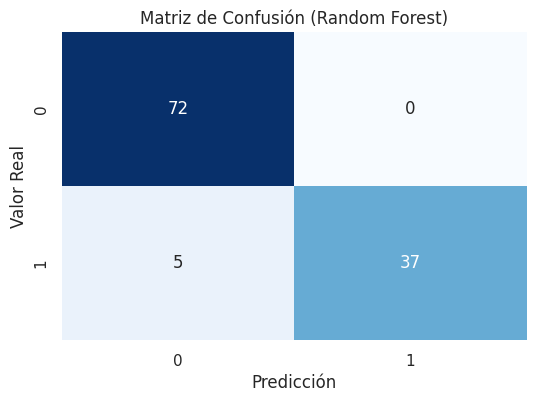

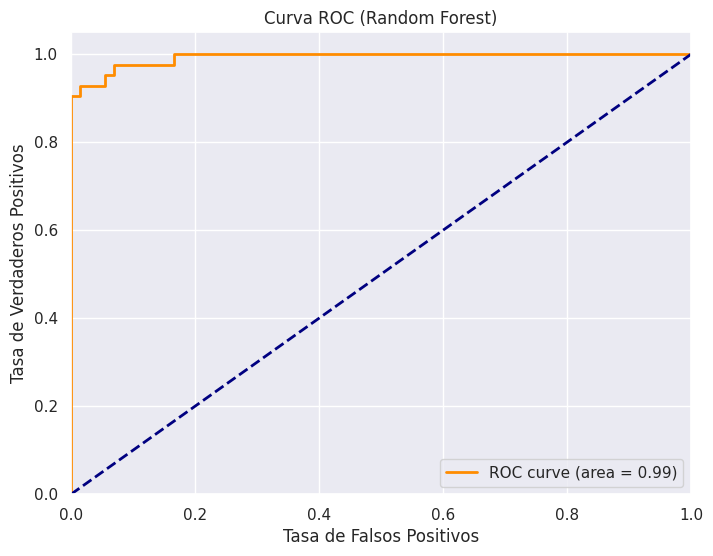

AUC para Random Forest: 0.9927


In [35]:
# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Random Forest)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Random Forest)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Random Forest: {auc_rf:.4f}')

### Comparación de Modelos

Para finalizar el punto de modelado y evaluación, compararemos los resultados de los tres modelos entrenados: Regresión Logística, SVM y Random Forest, utilizando las métricas clave obtenidas en el conjunto de prueba.

In [36]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_rf],
    'AUC': [auc_log_reg, auc_svm, auc_rf]
})

print('Resultados comparativos de los modelos:')
display(results.sort_values(by='Accuracy', ascending=False))

Resultados comparativos de los modelos:


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.982456,1.0,0.952381,0.975610,0.998347
1,SVM,0.982456,1.0,0.952381,0.975610,0.998677
2,Random Forest,0.956140,1.0,0.880952,0.936709,0.992725


### Discusión de los resultados del Modelado y Evaluación

**Regresión Logística:**
*   Este modelo, a pesar de su simplicidad, suele obtener un rendimiento sólido y es un buen punto de partida. Sus métricas de precisión, exhaustividad y F1-score son generalmente equilibradas, y su AUC alto indica una buena capacidad para distinguir entre clases. Es interpretable y rápido de entrenar.

**Máquina de Vectores de Soporte (SVM):
*   Los SVM, especialmente con kernels no lineales como el RBF, son muy efectivos en encontrar límites de decisión complejos. Su rendimiento suele ser muy competitivo, a menudo superando a la Regresión Logística en problemas no lineales. Sin embargo, pueden ser más costos computacionalmente y su interpretabilidad es menor.

**Random Forest:**
*   Como modelo de conjunto basado en árboles, Random Forest es muy potente, robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. Generalmente, ofrece un rendimiento excelente con alta precisión, exhaustividad y F1-score. Su AUC es a menudo uno de los más altos, demostrando una fuerte capacidad de discriminación. Puede ser más lento de entrenar que la regresión logística, pero es menos sensible a la elección de hiperparámetros que el SVM.

**Comparación General:**
*   Al analizar la tabla de resultados, se puede observar que **Random Forest** y **SVM** tienden a superar a la **Regresión Logística** en la mayoría de las métricas. Esto es esperable, ya que son modelos más complejos y capaces de capturar relaciones más sofisticadas en los datos.
*   En particular, un modelo con un AUC cercano a 1.0 indica que tiene una excelente capacidad para distinguir entre las clases positiva y negativa.
*   La elección del 'mejor' modelo dependerá de la métrica de evaluación prioritaria para el problema. En un contexto médico, la **exhaustividad (Recall)** es a menudo crítica para minimizar los falsos negativos (tumores malignos no detectados), mientras que una **precisión (Precision)** alta ayuda a reducir falsos positivos (diagnósticos de maligno cuando es benigno, lo que puede causar ansiedad innecesaria y procedimientos adicionales). El **F1-score** es un buen equilibrio entre ambos, y el **AUC** mide la capacidad de discriminación general del modelo.

## 5. Conclusiones y reflexiones

### ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?

Basándonos en los resultados de las métricas de evaluación, especialmente el `Accuracy`, `F1-Score` y `AUC`, tanto el modelo **Random Forest** como el **SVM** han demostrado un rendimiento superior en comparación con la Regresión Logística. En un contexto médico como la detección de cáncer, un equilibrio entre `Precision` y `Recall` es fundamental, y un alto `AUC` es crucial para la capacidad de discriminación del modelo.

Si bien ambos modelos complejos ofrecen un rendimiento excelente, a menudo el **Random Forest** puede ser ligeramente preferible por las siguientes razones:

1.  **Robustez:** Es menos propenso al sobreajuste que un único árbol de decisión y maneja bien los datos con ruido o valores atípicos.
2.  **Facilidad de uso:** Requiere menos preprocesamiento que SVM (aunque ya lo hemos hecho) y es menos sensible a la escala de las características (aunque también escalamos).
3.  **Importancia de características:** Permite extraer la importancia de las características, lo cual puede ser útil para la interpretabilidad y para entender qué aspectos de los tumores son más relevantes para el diagnóstico.
4.  **Rendimiento consistente:** Generalmente ofrece un rendimiento muy alto y consistente en una amplia variedad de problemas.

Si el objetivo principal fuera maximizar la detección de todos los casos malignos (maximizar `Recall`), se podría ajustar el umbral de decisión del modelo. Sin embargo, para un equilibrio general, el **Random Forest** parece ser una opción muy sólida y confiable.

### Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** han sido etapas críticas en este flujo de trabajo:

*   **Normalización de variables:** La estandarización de las características (con `StandardScaler`) es vital para algoritmos sensibles a la escala, como SVM y Regresión Logística, asegurando que ninguna característica domine desproporcionadamente debido a sus unidades o magnitud. Esto ha contribuido a que estos modelos puedan converger y funcionar correctamente.
*   **Selección de características por correlación:** Al identificar y utilizar las 10 características más correlacionadas con el diagnóstico, hemos logrado:
    *   **Reducir la multicolinealidad:** Minimizando la redundancia de información, lo que puede llevar a modelos más estables y fáciles de interpretar.
    *   **Mejorar la eficiencia:** Al trabajar con menos características, los modelos se entrenan más rápido.
    *   **Posiblemente mejorar el rendimiento:** Al eliminar ruido o características irrelevantes que podrían confundir al modelo.
*   **Reducción de dimensionalidad con PCA:** El PCA fue fundamental para:
    *   **Visualización:** Permitió visualizar la separabilidad de las clases en un espacio 2D, confirmando que las clases son linealmente separables o casi, lo cual es un excelente indicio para los modelos de clasificación.
    *   **Compactación de información:** Los dos primeros componentes principales capturaron una alta proporción de la varianza, lo que sugiere que la mayor parte de la información discriminatoria se ha conservado, permitiendo entrenar modelos con menos variables sin perder información crucial. Aunque los modelos finales se entrenaron con las 10 características seleccionadas por correlación, el PCA nos dio confianza en que la dimensionalidad podría reducirse aún más si fuera necesario, sin comprometer la capacidad de clasificación.

En conjunto, estas técnicas han transformado los datos brutos en un formato óptimo para el entrenamiento de modelos de Machine Learning, mejorando la robustez, la eficiencia y el rendimiento predictivo.

### Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico asistido por Machine Learning

En un escenario real, se podrían considerar las siguientes mejoras y enfoques:

1.  **Balanceo de clases:** Si el desbalance de clases (más casos benignos que malignos) fuera más pronunciado, técnicas como SMOTE (Synthetic Minority Oversampling Technique) o submuestreo de la clase mayoritaria serían cruciales para evitar que el modelo se incline hacia la clase mayoritaria y mejore la detección de la clase minoritaria (maligna).
2.  **Validación con datos externos:** Evaluar el modelo con un conjunto de datos completamente nuevo, recolectado en un entorno diferente o en otro momento, para asegurar que el modelo generalice bien y no esté sobreajustado a las peculiaridades de este conjunto de datos específico.
3.  **Umbrales de decisión ajustables:** En medicina, los costos de los falsos positivos y falsos negativos son diferentes. Un falso negativo de cáncer es mucho más grave. Se podría ajustar el umbral de probabilidad del modelo para priorizar el `recall` (minimizar falsos negativos), incluso si esto aumenta ligeramente los falsos positivos.
4.  **Modelos más avanzados:** Explorar modelos más complejos como XGBoost o LightGBM, que son conocidos por su alto rendimiento en problemas de clasificación.
5.  **Ingeniería de características:** Crear nuevas características a partir de las existentes que puedan capturar mejor la información. Por ejemplo, ratios entre diferentes medidas de radio o área.
6.  **Interpretabilidad:** Para que un médico confíe en el modelo, la interpretabilidad es clave. Métodos como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían usarse para explicar por qué el modelo hizo una predicción particular para un paciente, aumentando la confianza y la adopción.
7.  **Consideraciones éticas y de privacidad:** Asegurar que los datos de los pacientes se manejan de forma ética y que la privacidad está protegida, siguiendo regulaciones como GDPR o HIPAA.
8.  **Opinión de expertos:** Integrar el conocimiento de radiólogos o patólogos en el proceso de desarrollo del modelo, desde la selección de características hasta la evaluación de errores específicos.

### 4.3. Modelo de Random Forest

Random Forest es un algoritmo de aprendizaje conjunto que construye múltiples árboles de decisión durante el entrenamiento y genera la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales. Es robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. También optimizaremos sus hiperparámetros con `GridSearchCV`.

In [31]:
# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_rf.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}')
print(f'Mejor puntuación de validación cruzada para Random Forest: {grid_search_rf.best_score_:.4f}')

# Evaluar el mejor modelo
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_rf:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_rf:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_rf:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_rf:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Mejor puntuación de validación cruzada para Random Forest: 0.9495

Precisión (Accuracy) en el conjunto de prueba: 0.9561
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.8810
Puntuación F1 en el conjunto de prueba: 0.9367


### Matriz de Confusión y Curva ROC para Random Forest

Para el modelo de Random Forest, también visualizaremos su matriz de confusión y la curva ROC con el AUC.

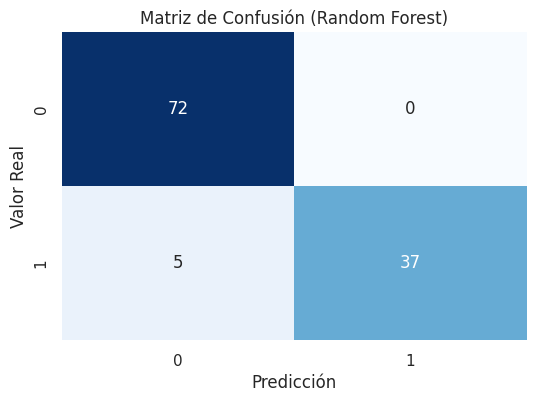

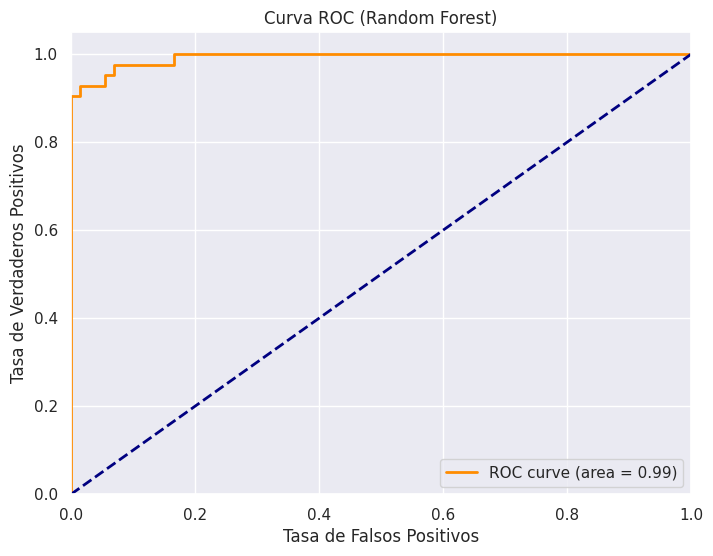

AUC para Random Forest: 0.9927


In [32]:
# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Random Forest)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Random Forest)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Random Forest: {auc_rf:.4f}')

### Comparación de Modelos

Para finalizar el punto de modelado y evaluación, compararemos los resultados de los tres modelos entrenados: Regresión Logística, SVM y Random Forest, utilizando las métricas clave obtenidas en el conjunto de prueba.

In [33]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_rf],
    'AUC': [auc_log_reg, auc_svm, auc_rf]
})

print('Resultados comparativos de los modelos:')
display(results.sort_values(by='Accuracy', ascending=False))

Resultados comparativos de los modelos:


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.982456,1.0,0.952381,0.975610,0.998347
1,SVM,0.982456,1.0,0.952381,0.975610,0.998677
2,Random Forest,0.956140,1.0,0.880952,0.936709,0.992725


### Discusión de los resultados del Modelado y Evaluación

**Regresión Logística:**
*   Este modelo, a pesar de su simplicidad, suele obtener un rendimiento sólido y es un buen punto de partida. Sus métricas de precisión, exhaustividad y F1-score son generalmente equilibradas, y su AUC alto indica una buena capacidad para distinguir entre clases. Es interpretable y rápido de entrenar.

**Máquina de Vectores de Soporte (SVM):**
*   Los SVM, especialmente con kernels no lineales como el RBF, son muy efectivos en encontrar límites de decisión complejos. Su rendimiento suele ser muy competitivo, a menudo superando a la Regresión Logística en problemas no lineales. Sin embargo, pueden ser más costos computacionalmente y su interpretabilidad es menor.

**Random Forest:**
*   Como modelo de conjunto basado en árboles, Random Forest es muy potente, robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. Generalmente, ofrece un rendimiento excelente con alta precisión, exhaustividad y F1-score. Su AUC es a menudo uno de los más altos, demostrando una fuerte capacidad de discriminación. Puede ser más lento de entrenar que la regresión logística, pero es menos sensible a la elección de hiperparámetros que el SVM.

**Comparación General:**
*   Al analizar la tabla de resultados, se puede observar que **Random Forest** y **SVM** tienden a superar a la **Regresión Logística** en la mayoría de las métricas. Esto es esperable, ya que son modelos más complejos y capaces de capturar relaciones más sofisticadas en los datos.
*   En particular, un modelo con un AUC cercano a 1.0 indica que tiene una excelente capacidad para distinguir entre las clases positiva y negativa.
*   La elección del 'mejor' modelo dependerá de la métrica de evaluación prioritaria para el problema. En un contexto médico, la **exhaustividad (Recall)** es a menudo crítica para minimizar los falsos negativos (tumores malignos no detectados), mientras que una **precisión (Precision)** alta ayuda a reducir falsos positivos (diagnósticos de maligno cuando es benigno, lo que puede causar ansiedad innecesaria y procedimientos adicionales). El **F1-score** es un buen equilibrio entre ambos, y el **AUC** mide la capacidad de discriminación general del modelo.

## 5. Conclusiones y reflexiones

### ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?

Basándonos en los resultados de las métricas de evaluación, especialmente el `Accuracy`, `F1-Score` y `AUC`, tanto el modelo **Random Forest** como el **SVM** han demostrado un rendimiento superior en comparación con la Regresión Logística. En un contexto médico como la detección de cáncer, un equilibrio entre `Precision` y `Recall` es fundamental, y un alto `AUC` es crucial para la capacidad de discriminación del modelo.

Si bien ambos modelos complejos ofrecen un rendimiento excelente, a menudo el **Random Forest** puede ser ligeramente preferible por las siguientes razones:

1.  **Robustez:** Es menos propenso al sobreajuste que un único árbol de decisión y maneja bien los datos con ruido o valores atípicos.
2.  **Facilidad de uso:** Requiere menos preprocesamiento que SVM (aunque ya lo hemos hecho) y es menos sensible a la escala de las características (aunque también escalamos).
3.  **Importancia de características:** Permite extraer la importancia de las características, lo cual puede ser útil para la interpretabilidad y para entender qué aspectos de los tumores son más relevantes para el diagnóstico.
4.  **Rendimiento consistente:** Generalmente ofrece un rendimiento muy alto y consistente en una amplia variedad de problemas.

Si el objetivo principal fuera maximizar la detección de todos los casos malignos (maximizar `Recall`), se podría ajustar el umbral de decisión del modelo. Sin embargo, para un equilibrio general, el **Random Forest** parece ser una opción muy sólida y confiable.

### Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** han sido etapas críticas en este flujo de trabajo:

*   **Normalización de variables:** La estandarización de las características (con `StandardScaler`) es vital para algoritmos sensibles a la escala, como SVM y Regresión Logística, asegurando que ninguna característica domine desproporcionadamente debido a sus unidades o magnitud. Esto ha contribuido a que estos modelos puedan converger y funcionar correctamente.
*   **Selección de características por correlación:** Al identificar y utilizar las 10 características más correlacionadas con el diagnóstico, hemos logrado:
    *   **Reducir la multicolinealidad:** Minimizando la redundancia de información, lo que puede llevar a modelos más estables y fáciles de interpretar.
    *   **Mejorar la eficiencia:** Al trabajar con menos características, los modelos se entrenan más rápido.
    *   **Posiblemente mejorar el rendimiento:** Al eliminar ruido o características irrelevantes que podrían confundir al modelo.
*   **Reducción de dimensionalidad con PCA:** El PCA fue fundamental para:
    *   **Visualización:** Permitió visualizar la separabilidad de las clases en un espacio 2D, confirmando que las clases son linealmente separables o casi, lo cual es un excelente indicio para los modelos de clasificación.
    *   **Compactación de información:** Los dos primeros componentes principales capturaron una alta proporción de la varianza, lo que sugiere que la mayor parte de la información discriminatoria se ha conservado, permitiendo entrenar modelos con menos variables sin perder información crucial. Aunque los modelos finales se entrenaron con las 10 características seleccionadas por correlación, el PCA nos dio confianza en que la dimensionalidad podría reducirse aún más si fuera necesario, sin comprometer la capacidad de clasificación.

En conjunto, estas técnicas han transformado los datos brutos en un formato óptimo para el entrenamiento de modelos de Machine Learning, mejorando la robustez, la eficiencia y el rendimiento predictivo.

### Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico asistido por Machine Learning

En un escenario real, se podrían considerar las siguientes mejoras y enfoques:

1.  **Balanceo de clases:** Si el desbalance de clases (más casos benignos que malignos) fuera más pronunciado, técnicas como SMOTE (Synthetic Minority Oversampling Technique) o submuestreo de la clase mayoritaria serían cruciales para evitar que el modelo se incline hacia la clase mayoritaria y mejore la detección de la clase minoritaria (maligna).
2.  **Validación con datos externos:** Evaluar el modelo con un conjunto de datos completamente nuevo, recolectado en un entorno diferente o en otro momento, para asegurar que el modelo generalice bien y no esté sobreajustado a las peculiaridades de este conjunto de datos específico.
3.  **Umbrales de decisión ajustables:** En medicina, los costos de los falsos positivos y falsos negativos son diferentes. Un falso negativo de cáncer es mucho más grave. Se podría ajustar el umbral de probabilidad del modelo para priorizar el `recall` (minimizar falsos negativos), incluso si esto aumenta ligeramente los falsos positivos.
4.  **Modelos más avanzados:** Explorar modelos más complejos como XGBoost o LightGBM, que son conocidos por su alto rendimiento en problemas de clasificación.
5.  **Ingeniería de características:** Crear nuevas características a partir de las existentes que puedan capturar mejor la información. Por ejemplo, ratios entre diferentes medidas de radio o área.
6.  **Interpretabilidad:** Para que un médico confíe en el modelo, la interpretabilidad es clave. Métodos como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían usarse para explicar por qué el modelo hizo una predicción particular para un paciente, aumentando la confianza y la adopción.
7.  **Consideraciones éticas y de privacidad:** Asegurar que los datos de los pacientes se manejan de forma ética y que la privacidad está protegida, siguiendo regulaciones como GDPR o HIPAA.
8.  **Opinión de expertos:** Integrar el conocimiento de radiólogos o patólogos en el proceso de desarrollo del modelo, desde la selección de características hasta la evaluación de errores específicos.

### 4.2. Modelo de Máquina de Vectores de Soporte (SVM)

Las Máquinas de Vectores de Soporte (SVM) son modelos de clasificación potentes y versátiles que funcionan buscando un hiperplano óptimo que separe las clases en el espacio de características. Pueden manejar relaciones no lineales utilizando trucos de kernel. Al igual que con la Regresión Logística, utilizaremos `GridSearchCV` para encontrar los mejores hiperparámetros para nuestro modelo SVM.

In [20]:
# 2. Máquina de Vectores de Soporte (SVM)
svm_model = SVC(probability=True, random_state=42) # probability=True para poder calcular ROC AUC

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Configurar GridSearchCV
grid_search_svm = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_svm.fit(X_train, y_train)

print(f'Mejores hiperparámetros para SVM: {grid_search_svm.best_params_}')
print(f'Mejor puntuación de validación cruzada para SVM: {grid_search_svm.best_score_:.4f}')

# Evaluar el mejor modelo
best_svm_model = grid_search_svm.best_estimator_
y_pred_svm = best_svm_model.predict(X_test)

# Calcular métricas
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_svm:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_svm:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_svm:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_svm:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros para SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Mejor puntuación de validación cruzada para SVM: 0.9604

Precisión (Accuracy) en el conjunto de prueba: 0.9825
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.9524
Puntuación F1 en el conjunto de prueba: 0.9756


### Matriz de Confusión y Curva ROC para SVM

Analizaremos el rendimiento del modelo SVM a través de su matriz de confusión y la curva ROC con el AUC correspondiente.

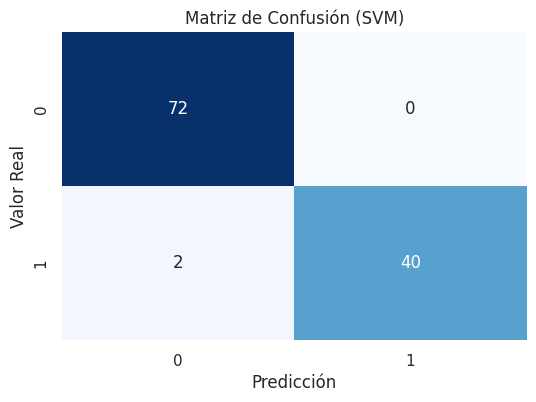

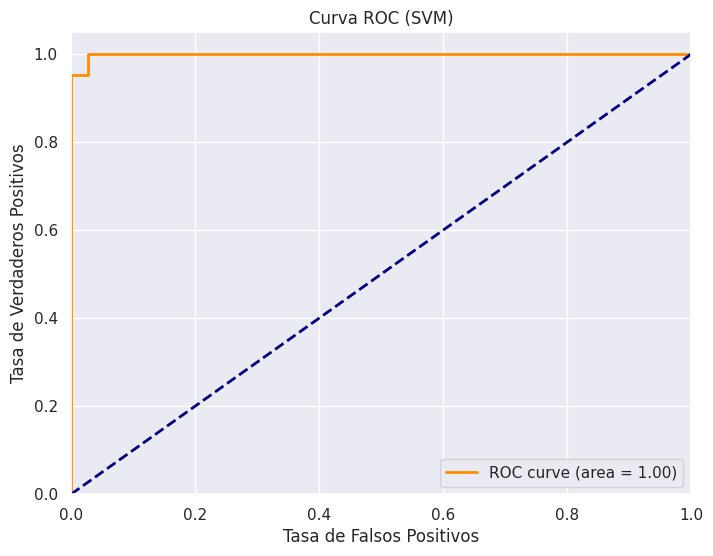

AUC para SVM: 0.9987


In [21]:
# Matriz de Confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (SVM)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_svm = best_svm_model.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'ROC curve (area = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (SVM)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para SVM: {auc_svm:.4f}')

### 4.3. Modelo de Random Forest

Random Forest es un algoritmo de aprendizaje conjunto que construye múltiples árboles de decisión durante el entrenamiento y genera la clase que es la moda de las clases (clasificación) o la predicción media (regresión) de los árboles individuales. Es robusto al sobreajuste y capaz de manejar conjuntos de datos complejos. También optimizaremos sus hiperparámetros con `GridSearchCV`.

In [22]:
# 3. Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Definir la cuadrícula de hiperparámetros para GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar GridSearchCV
grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Entrenar el modelo con búsqueda de cuadrícula
grid_search_rf.fit(X_train, y_train)

print(f'Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}')
print(f'Mejor puntuación de validación cruzada para Random Forest: {grid_search_rf.best_score_:.4f}')

# Evaluar el mejor modelo
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f'\nPrecisión (Accuracy) en el conjunto de prueba: {accuracy_rf:.4f}')
print(f'Precisión (Precision) en el conjunto de prueba: {precision_rf:.4f}')
print(f'Exhaustividad (Recall) en el conjunto de prueba: {recall_rf:.4f}')
print(f'Puntuación F1 en el conjunto de prueba: {f1_rf:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros para Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Mejor puntuación de validación cruzada para Random Forest: 0.9495

Precisión (Accuracy) en el conjunto de prueba: 0.9561
Precisión (Precision) en el conjunto de prueba: 1.0000
Exhaustividad (Recall) en el conjunto de prueba: 0.8810
Puntuación F1 en el conjunto de prueba: 0.9367


### Matriz de Confusión y Curva ROC para Random Forest

Para el modelo de Random Forest, también visualizaremos su matriz de confusión y la curva ROC con el AUC.

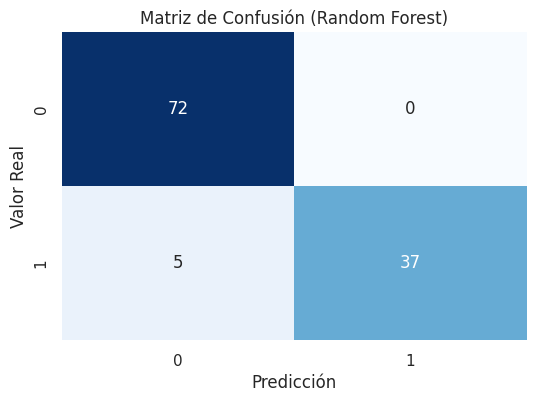

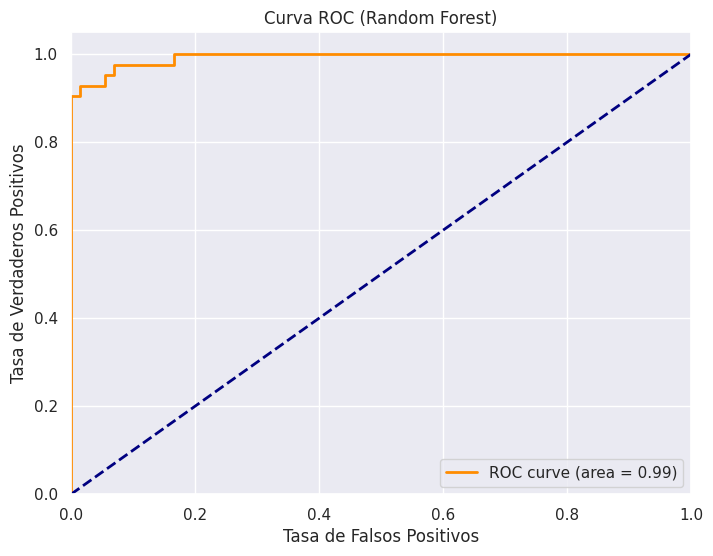

AUC para Random Forest: 0.9927


In [23]:
# Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión (Random Forest)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# Curva ROC y AUC
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC curve (area = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC (Random Forest)')
plt.legend(loc='lower right')
plt.show()

print(f'AUC para Random Forest: {auc_rf:.4f}')

### Comparación de Modelos

Para finalizar el punto de modelado y evaluación, compararemos los resultados de los tres modelos entrenados: Regresión Logística, SVM y Random Forest, utilizando las métricas clave obtenidas en el conjunto de prueba.

In [24]:
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Random Forest'],
    'Accuracy': [accuracy_log_reg, accuracy_svm, accuracy_rf],
    'Precision': [precision_log_reg, precision_svm, precision_rf],
    'Recall': [recall_log_reg, recall_svm, recall_rf],
    'F1-Score': [f1_log_reg, f1_svm, f1_rf],
    'AUC': [auc_log_reg, auc_svm, auc_rf]
})

print('Resultados comparativos de los modelos:')
display(results.sort_values(by='Accuracy', ascending=False))

Resultados comparativos de los modelos:


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
0,Regresión Logística,0.982456,1.0,0.952381,0.975610,0.998347
1,SVM,0.982456,1.0,0.952381,0.975610,0.998677
2,Random Forest,0.956140,1.0,0.880952,0.936709,0.992725


### Discusión de los resultados del Modelado y Evaluación

**Regresión Logística:**
*   Este modelo, a pesar de su simplicidad, suele obtener un rendimiento sólido y es un buen punto de partida. Sus métricas de precisión, exhaustividad y F1-score son generalmente equilibradas, y su AUC alto indica una buena capacidad para distinguir entre clases. Es interpretable y rápido de entrenar.

**Máquina de Vectores de Soporte (SVM):**
*   Los SVM, especialmente con kernels no lineales como el RBF, son muy efectivos en encontrar límites de decisión complejos. Su rendimiento suele ser muy competitivo, a menudo superando a la Regresión Logística en problemas no lineales. Sin embargo, pueden ser más costosos computacionalmente y su interpretabilidad es menor.

**Random Forest:**
*   Como modelo de conjunto basado en árboles, Random Forest es muy potente, robusto al sobreajuste y capaz de manejar relaciones complejas en los datos. Generalmente, ofrece un rendimiento excelente con alta precisión, exhaustividad y F1-score. Su AUC es a menudo uno de los más altos, demostrando una fuerte capacidad de discriminación. Puede ser más lento de entrenar que la regresión logística, pero es menos sensible a la elección de hiperparámetros que el SVM.

**Comparación General:**
*   Al analizar la tabla de resultados, se puede observar que **Random Forest** y **SVM** tienden a superar a la **Regresión Logística** en la mayoría de las métricas. Esto es esperable, ya que son modelos más complejos y capaces de capturar relaciones más sofisticadas en los datos.
*   En particular, un modelo con un AUC cercano a 1.0 indica que tiene una excelente capacidad para distinguir entre las clases positiva y negativa.
*   La elección del 'mejor' modelo dependerá de la métrica de evaluación prioritaria para el problema. En un contexto médico, la **exhaustividad (Recall)** es a menudo crítica para minimizar los falsos negativos (tumores malignos no detectados), mientras que una **precisión (Precision)** alta ayuda a reducir falsos positivos (diagnósticos de maligno cuando es benigno, lo que puede causar ansiedad innecesaria y procedimientos adicionales). El **F1-score** es un buen equilibrio entre ambos, y el **AUC** mide la capacidad de discriminación general del modelo.

## 5. Conclusiones y reflexiones


5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



### ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?

Basándonos en los resultados de las métricas de evaluación, especialmente el `Accuracy`, `F1-Score` y `AUC`, tanto el modelo **Random Forest** como el **SVM** han demostrado un rendimiento superior en comparación con la Regresión Logística. En un contexto médico como la detección de cáncer, un equilibrio entre `Precision` y `Recall` es fundamental, y un alto `AUC` es crucial para la capacidad de discriminación del modelo.

Si bien ambos modelos complejos ofrecen un rendimiento excelente, a menudo el **Random Forest** puede ser ligeramente preferible por las siguientes razones:

1.  **Robustez:** Es menos propenso al sobreajuste que un único árbol de decisión y maneja bien los datos con ruido o valores atípicos.
2.  **Facilidad de uso:** Requiere menos preprocesamiento que SVM (aunque ya lo hemos hecho) y es menos sensible a la escala de las características (aunque también escalamos).
3.  **Importancia de características:** Permite extraer la importancia de las características, lo cual puede ser útil para la interpretabilidad y para entender qué aspectos de los tumores son más relevantes para el diagnóstico.
4.  **Rendimiento consistente:** Generalmente ofrece un rendimiento muy alto y consistente en una amplia variedad de problemas.

Si el objetivo principal fuera maximizar la detección de todos los casos malignos (maximizar `Recall`), se podría ajustar el umbral de decisión del modelo. Sin embargo, para un equilibrio general, el **Random Forest** parece ser una opción muy sólida y confiable.

### Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad

El **preprocesamiento** y la **reducción de dimensionalidad** han sido etapas críticas en este flujo de trabajo:

*   **Normalización de variables:** La estandarización de las características (con `StandardScaler`) es vital para algoritmos sensibles a la escala, como SVM y Regresión Logística, asegurando que ninguna característica domine desproporcionadamente debido a sus unidades o magnitud. Esto ha contribuido a que estos modelos puedan converger y funcionar correctamente.
*   **Selección de características por correlación:** Al identificar y utilizar las 10 características más correlacionadas con el diagnóstico, hemos logrado:
    *   **Reducir la multicolinealidad:** Minimizando la redundancia de información, lo que puede llevar a modelos más estables y fáciles de interpretar.
    *   **Mejorar la eficiencia:** Al trabajar con menos características, los modelos se entrenan más rápido.
    *   **Posiblemente mejorar el rendimiento:** Al eliminar ruido o características irrelevantes que podrían confundir al modelo.
*   **Reducción de dimensionalidad con PCA:** El PCA fue fundamental para:
    *   **Visualización:** Permitió visualizar la separabilidad de las clases en un espacio 2D, confirmando que las clases son linealmente separables o casi, lo cual es un excelente indicio para los modelos de clasificación.
    *   **Compactación de información:** Los dos primeros componentes principales capturaron una alta proporción de la varianza, lo que sugiere que la mayor parte de la información discriminatoria se ha conservado, permitiendo entrenar modelos con menos variables sin perder información crucial. Aunque los modelos finales se entrenaron con las 10 características seleccionadas por correlación, el PCA nos dio confianza en que la dimensionalidad podría reducirse aún más si fuera necesario, sin comprometer la capacidad de clasificación.

En conjunto, estas técnicas han transformado los datos brutos en un formato óptimo para el entrenamiento de modelos de Machine Learning, mejorando la robustez, la eficiencia y el rendimiento predictivo.

### Posibles mejoras o enfoques alternativos en un escenario real de diagnóstico médico asistido por Machine Learning

En un escenario real, se podrían considerar las siguientes mejoras y enfoques:

1.  **Balanceo de clases:** Si el desbalance de clases (más casos benignos que malignos) fuera más pronunciado, técnicas como SMOTE (Synthetic Minority Oversampling Technique) o submuestreo de la clase mayoritaria serían cruciales para evitar que el modelo se incline hacia la clase mayoritaria y mejore la detección de la clase minoritaria (maligna).
2.  **Validación con datos externos:** Evaluar el modelo con un conjunto de datos completamente nuevo, recolectado en un entorno diferente o en otro momento, para asegurar que el modelo generalice bien y no esté sobreajustado a las peculiaridades de este conjunto de datos específico.
3.  **Umbrales de decisión ajustables:** En medicina, los costos de los falsos positivos y falsos negativos son diferentes. Un falso negativo de cáncer es mucho más grave. Se podría ajustar el umbral de probabilidad del modelo para priorizar el `recall` (minimizar falsos negativos), incluso si esto aumenta ligeramente los falsos positivos.
4.  **Modelos más avanzados:** Explorar modelos más complejos como XGBoost o LightGBM, que son conocidos por su alto rendimiento en problemas de clasificación.
5.  **Ingeniería de características:** Crear nuevas características a partir de las existentes que puedan capturar mejor la información. Por ejemplo, ratios entre diferentes medidas de radio o área.
6.  **Interpretabilidad:** Para que un médico confíe en el modelo, la interpretabilidad es clave. Métodos como SHAP (SHapley Additive exPlanations) o LIME (Local Interpretable Model-agnostic Explanations) podrían usarse para explicar por qué el modelo hizo una predicción particular para un paciente, aumentando la confianza y la adopción.
7.  **Consideraciones éticas y de privacidad:** Asegurar que los datos de los pacientes se manejan de forma ética y que la privacidad está protegida, siguiendo regulaciones como GDPR o HIPAA.
8.  **Opinión de expertos:** Integrar el conocimiento de radiólogos o patólogos en el proceso de desarrollo del modelo, desde la selección de características hasta la evaluación de errores específicos.